In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import os
from scipy import stats

import anndata as ad
import scanpy as sc
#import episcanpy as epi

plt.rcParams["figure.figsize"]= (4, 4)

/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
import scipy
scipy.__version__

'1.17.0'

In [3]:
import sys
print(sys. version)

3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:46:25) [GCC 14.3.0]


# Load the data

In [4]:
df = pd.read_csv('WIM13335_PD24_SwissMouse_perc_PrecDet_int_top3av_ratio_TTEST_Peptides (1).csv',
                sep=';')
df

,Checked,Confidence,Annotated Sequence,Modifications,Qvality PEP,Qvality q-value,# Protein Groups,# Proteins,# PSMs,Master Protein Accessions,...,"Found in Sample: [S8] F8: Sample, VPR","Found in Sample: [S9] F9: Sample, VPR","Found in Sample: [S10] F10: Sample, VPR","Found in Sample: [S11] F11: Sample, VPR","Found in Sample: [S12] F12: Sample, VPR",Confidence (by Search Engine): Sequest HT,Percolator q-Value (by Search Engine): Sequest HT,Percolator PEP (by Search Engine): Sequest HT,XCorr (by Search Engine): Sequest HT,Top Apex RT [min]
0,False,High,[R].GTSFEAAATSGGSASSEK.[A],NaN,"8,50702E-06","0,000037994",1,1,34,Q99LC5,...,High,High,High,High,High,High,"0,00000692","6,024E-15","2,94","31,55"
1,False,High,[R].KSDIYVCMISYAHNVAAQGK.[Y],1xCarbamidomethyl [C7],"1,47813E-05","0,000037994",1,1,2,P50396,...,High,Not Found,High,Not Found,Not Found,High,"0,00000692","2,007E-13","2,17",NaN
2,False,High,[R].KSDIYVCMISFAHNVAAQGK.[Y],1xCarbamidomethyl [C7],"1,516E-08","0,000037994",1,1,5,Q61598,...,High,Peak Found,High,Peak Found,Peak Found,High,"0,00000692","6,305E-16","3,45","89,25"
3,False,High,[R].KSDLFQDDLYPDTAGPEAALEAEEWFEGK.[N],NaN,"1,55548E-09","0,000037994",1,1,10,Q9WUM4,...,High,High,High,High,High,High,"0,00000692","6,305E-16","5,47","100,99"
4,False,High,[K].KSDIDEIVLVGGSTR.[I],NaN,"1,01436E-07","0,000037994",1,1,37,P20029,...,High,High,High,High,High,High,"0,00000692","6,305E-16","3,44","64,47"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50527,False,High,[K].LEEVMAQLEEEK.[K],1xOxidation [M5],"0,151933","0,00998909",1,1,1,B9EJA2,...,Not Found,Not Found,Not Found,Not Found,Not Found,High,"0,002176","0,03323","1,14",NaN
50528,False,High,[K].LEHEYIQNFK.[I],1xDeamidated [Q7],"0,151933","0,00998909",1,1,1,Q61166,...,Not Found,Not Found,Not Found,High,Not Found,High,"0,002176","0,0334","1,06",NaN
50529,False,High,[R].AASEAGGPAR.[L],NaN,"0,151933","0,00998909",1,1,1,P35569,...,Peak Found,High,Peak Found,Peak Found,Peak Found,High,"0,002176","0,03329","0,96","26,72"
50530,False,High,[R].YQFDPNLGIR.[Q],NaN,"0,151933","0,00998909",1,1,3,Q6PDI5,...,Peak Found,Peak Found,High,High,Peak Found,High,"0,002176","0,03331","1,54","70,15"


In [5]:
gtf_file = "gencode.vM35.chr_patch_hapl_scaff.annotation.gtf"
df1 = pd.read_csv(gtf_file, skiprows=5, header=None, sep='\t')
df1 = df1[df1[2]=='transcript'].copy()

ensmust = []
gene_name = []
for line in df1[8].tolist():
    line= line.split(';')
    ensmust_current="NA"
    gene_name_current="NA"
    for element in line : 
        if 'transcript_id' in element:
            ensmust_current = element.split('"')[-2]
        elif 'gene_name' in element:
            gene_name_current =  element.split('"')[-2]
    if gene_name != 'NA':
        ensmust.append(ensmust_current)
        gene_name.append(gene_name_current)

df2 = pd.DataFrame()
df2['ENSMUST']=ensmust
df2['gene name']=gene_name
df2.index=df2['ENSMUST'].tolist()


###############

prot_file='gencode.vM35.metadata.SwissProt'
df3 = pd.read_csv(prot_file, header=None, sep='\t')
df3.index = df3[0].tolist()
df3.columns=['ensembl_id', 'uniprot_label', 'unitprot_label2']

###############

df_names = df2.merge(df3, left_index=True, right_index=True)
df_names.index = df_names['uniprot_label'].tolist()
df_names

,ENSMUST,gene name,ensembl_id,uniprot_label,unitprot_label2
Q5GH67,ENSMUST00000070533.5,Xkr4,ENSMUST00000070533.5,Q5GH67,Q5GH67.111
P56716,ENSMUST00000027032.6,Rp1,ENSMUST00000027032.6,P56716,P56716.144
Q61473,ENSMUST00000027035.10,Sox17,ENSMUST00000027035.10,Q61473,Q61473.180
Q61473,ENSMUST00000195555.2,Sox17,ENSMUST00000195555.2,Q61473,Q61473.180
Q61473,ENSMUST00000116652.8,Sox17,ENSMUST00000116652.8,Q61473,Q61473.180
...,...,...,...,...,...
P03903,ENSMUST00000084013.1,mt-Nd4l,ENSMUST00000084013.1,P03903,P03903.143
P03911,ENSMUST00000082414.1,mt-Nd4,ENSMUST00000082414.1,P03911,P03911.160
P03921,ENSMUST00000082418.1,mt-Nd5,ENSMUST00000082418.1,P03921,P03921.152
P03925,ENSMUST00000082419.1,mt-Nd6,ENSMUST00000082419.1,P03925,P03925.137


In [6]:
gene_name = []
missing_gene_names = []

for prot in df['Master Protein Accessions'].tolist():
    
    if prot not in df_names.index.tolist():
        #print(prot)
        gene_name.append('missing protein name')
        missing_gene_names.append(prot)
    elif type(df_names.loc[prot]['gene name']) ==str:
        gene_name.append(df_names.loc[prot]['gene name'])
    else:
        gene_name.append(df_names.loc[prot]['gene name'].tolist()[0])
len(set(gene_name))
df['gene_name'] = gene_name

# Format the dataframe to fit with the AnnData data structure

In [7]:
samples = ['Abundances (Normalized): F1: Sample, noVPR',
       'Abundances (Normalized): F2: Sample, noVPR',
       'Abundances (Normalized): F3: Sample, noVPR',
       'Abundances (Normalized): F4: Sample, noVPR',
       'Abundances (Normalized): F5: Sample, noVPR',
       'Abundances (Normalized): F6: Sample, noVPR',
       'Abundances (Normalized): F7: Sample, VPR',
       'Abundances (Normalized): F8: Sample, VPR',
       'Abundances (Normalized): F9: Sample, VPR',
       'Abundances (Normalized): F10: Sample, VPR',
       'Abundances (Normalized): F11: Sample, VPR',
       'Abundances (Normalized): F12: Sample, VPR']

df2 = df[samples]
df2

for column in df2.columns:
    df2[column] = [float('.'.join(str(x).split(','))) for x in df2[column].tolist()]

samples2 = ['Abundances Count: F1: Sample, noVPR',
       'Abundances Count: F2: Sample, noVPR',
       'Abundances Count: F3: Sample, noVPR',
       'Abundances Count: F4: Sample, noVPR',
       'Abundances Count: F5: Sample, noVPR',
       'Abundances Count: F6: Sample, noVPR',
       'Abundances Count: F7: Sample, VPR',
       'Abundances Count: F8: Sample, VPR',
       'Abundances Count: F9: Sample, VPR',
       'Abundances Count: F10: Sample, VPR',
       'Abundances Count: F11: Sample, VPR',
       'Abundances Count: F12: Sample, VPR']

df3 = df[samples2]
df3

for column in df3.columns:
    df3[column] = [float('.'.join(str(x).split(','))) for x in df3[column].tolist()]

samples2 = ['Abundance: F1: Sample, noVPR', 'Abundance: F2: Sample, noVPR',
       'Abundance: F3: Sample, noVPR', 'Abundance: F4: Sample, noVPR',
       'Abundance: F5: Sample, noVPR', 'Abundance: F6: Sample, noVPR',
       'Abundance: F7: Sample, VPR', 'Abundance: F8: Sample, VPR',
       'Abundance: F9: Sample, VPR', 'Abundance: F10: Sample, VPR',
       'Abundance: F11: Sample, VPR', 'Abundance: F12: Sample, VPR']

df4 = df[samples2]
df4

for column in df4.columns:
    df4[column] = [float('.'.join(str(x).split(','))) for x in df4[column].tolist()]

/tmp/ipykernel_49360/3196888165.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[column] = [float('.'.join(str(x).split(','))) for x in df2[column].tolist()]
/tmp/ipykernel_49360/3196888165.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3[column] = [float('.'.join(str(x).split(','))) for x in df3[column].tolist()]
/tmp/ipykernel_49360/3196888165.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [8]:
meta = ['Annotated Sequence', 'Modifications',
       'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins',
       '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins',
       'Modifications in Master Proteins', '# Missed Cleavages',
       'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name']

adata =ad.AnnData(df2).transpose()
adata.var_names=df['Master Protein Accessions'].tolist()
adata.var=df[meta]
adata.layers['raw_counts']=np.array(df3).transpose()
adata.layers['raw_counts_2']=np.array(df4).transpose()
adata.X = np.nan_to_num(adata.X)
adata.layers['raw_counts'] = np.nan_to_num(adata.layers['raw_counts'])
adata.layers['raw_counts_2'] = np.nan_to_num(adata.layers['raw_counts_2'])
adata.obs['VPR_condition'] =['noVPR']*6+['VPR']*6
adata.obs['replicates'] = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']+['R1', 'R2', 'R3', 'R4', 'R5', 'R6']

adata

/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 12 × 50532
    obs: 'VPR_condition', 'replicates'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name'
    layers: 'raw_counts', 'raw_counts_2'

# Filtering and QC

In [9]:
sc.pp.filter_genes(adata, min_cells=0)
#epi.pp.qc_stats(adata, verbose=True)
#sc.pl.violin(adata.transpose(), keys='n_cells')
adata.var['n_samples'] = adata.var['n_cells']
del adata.var['n_cells']

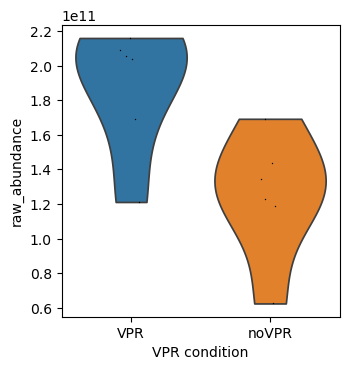

<Axes: xlabel='VPR_condition', ylabel='raw_abundance'>

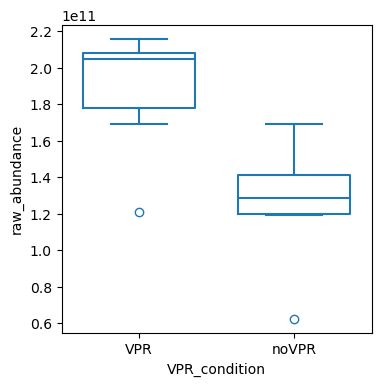

In [10]:
#sc.pl.violin(adata, 'n_counts', groupby='VPR_condition')
#sns.boxplot(data=adata.obs, x="VPR_condition", y="n_counts", fill=False, gap=.1)

adata.obs['raw_abundance'] = np.sum(adata.layers['raw_counts_2'], axis=1).tolist()
sc.pl.violin(adata, 'raw_abundance', groupby='VPR_condition')
sns.boxplot(data=adata.obs, x="VPR_condition", y="raw_abundance", fill=False, gap=.1)

### Welch test comparing the raw peptide abundance between VPR and no VPR conditions

In [11]:
VPR_abundance = adata.obs['raw_abundance'][:6]
noVPR_abundance = adata.obs['raw_abundance'][6:]
stats.ttest_ind(VPR_abundance, noVPR_abundance)

TtestResult(statistic=np.float64(-2.9899929411857356), pvalue=np.float64(0.013573821271003587), df=np.float64(10.0))

# Filter out peptides and get protein level quantification

In [12]:
adata

AnnData object with n_obs × n_vars = 12 × 50532
    obs: 'VPR_condition', 'replicates', 'raw_abundance'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name', 'n_samples'
    uns: 'VPR_condition_colors'
    layers: 'raw_counts', 'raw_counts_2'

### tag the peptides that are assigned to more than one protein 

In [13]:
nb_peptides=[]
for line in adata.var['Master Protein Accessions'].tolist():
    if type(line)==float:
        nb_peptides.append(0)
    else:
        line = line.split(';')
        nb_peptides.append(len(line))

### So there is 2 peptides not assigned to any proteins
### There is 50532 different peptides
### There is 1555 peptides assigned to more than one protein

In [14]:
### So now, we remove the peptides assigned to no proteins
adata.var['nb_peptides'] = nb_peptides
adata = adata[:,adata.var['nb_peptides']>0].copy()
adata

AnnData object with n_obs × n_vars = 12 × 50530
    obs: 'VPR_condition', 'replicates', 'raw_abundance'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name', 'n_samples', 'nb_peptides'
    uns: 'VPR_condition_colors'
    layers: 'raw_counts', 'raw_counts_2'

In [15]:
### Now we want to know for each protein how many peptide there is... 
# But for now I will only consider peptides assigned to a single protein

In [16]:
adata = adata[:,adata.var['nb_peptides']==1].copy()
adata

AnnData object with n_obs × n_vars = 12 × 48975
    obs: 'VPR_condition', 'replicates', 'raw_abundance'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name', 'n_samples', 'nb_peptides'
    uns: 'VPR_condition_colors'
    layers: 'raw_counts', 'raw_counts_2'

In [17]:
list_prot = []
prot_pep_count = []
dict_prot = {}
for prot in set(adata.var['Master Protein Accessions']):
    list_prot.append(prot)
    dict_prot[prot]= adata.var['Master Protein Accessions'].tolist().count(prot)
    prot_pep_count.append(adata.var['Master Protein Accessions'].tolist().count(prot))


label = []
for prot in adata.var['Master Protein Accessions'].tolist():
    label.append(dict_prot[prot])
adata.var['nb_peptide_for_prot'] = label

In [18]:
# remove peptides detected in less than 3 samples
adata = adata[:,adata.var['n_samples']>=3].copy()
adata

AnnData object with n_obs × n_vars = 12 × 40406
    obs: 'VPR_condition', 'replicates', 'raw_abundance'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name', 'n_samples', 'nb_peptides', 'nb_peptide_for_prot'
    uns: 'VPR_condition_colors'
    layers: 'raw_counts', 'raw_counts_2'

In [19]:
# remove proteins with less then 2 peptides measured
adata = adata[:,adata.var['nb_peptide_for_prot']>=2].copy()
adata

AnnData object with n_obs × n_vars = 12 × 39620
    obs: 'VPR_condition', 'replicates', 'raw_abundance'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name', 'n_samples', 'nb_peptides', 'nb_peptide_for_prot'
    uns: 'VPR_condition_colors'
    layers: 'raw_counts', 'raw_counts_2'

In [20]:
# remains peptide to measure 4060 different proteins
len(set(adata.var['Master Protein Accessions']))

4060

In [21]:
# that's to find differential proteins 
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9514008/

In [64]:
#raw peptide abundance plot 
adata.obs

,VPR_condition,replicates,raw_abundance,n_counts,VPR_condition_coordinates
"Abundances (Normalized): F1: Sample, noVPR",noVPR,R1,1.126365e+11,1.265831e+11,0
"Abundances (Normalized): F2: Sample, noVPR",noVPR,R2,1.421331e+11,1.338196e+11,0
"Abundances (Normalized): F3: Sample, noVPR",noVPR,R3,5.218524e+10,1.131594e+11,0
"Abundances (Normalized): F4: Sample, noVPR",noVPR,R4,1.031366e+11,1.284250e+11,0
"Abundances (Normalized): F5: Sample, noVPR",noVPR,R5,9.980697e+10,1.290845e+11,0
"Abundances (Normalized): F6: Sample, noVPR",noVPR,R6,1.206221e+11,1.277388e+11,0
"Abundances (Normalized): F7: Sample, VPR",VPR,R1,1.421036e+11,1.291939e+11,1
"Abundances (Normalized): F8: Sample, VPR",VPR,R2,1.719343e+11,1.311881e+11,1
"Abundances (Normalized): F9: Sample, VPR",VPR,R3,1.020953e+11,1.268498e+11,1
"Abundances (Normalized): F10: Sample, VPR",VPR,R4,1.756140e+11,1.266253e+11,1


# Plot the raw peptide abundance

In [23]:
sc.pp.filter_cells(adata, min_counts=0)

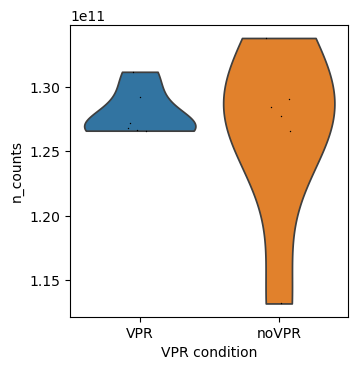

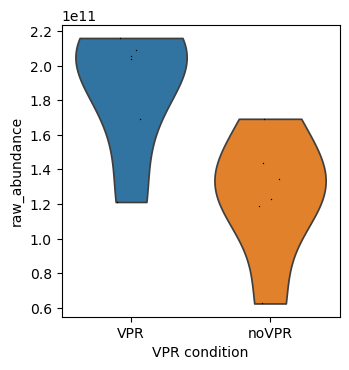

<Axes: xlabel='VPR_condition', ylabel='raw_abundance'>

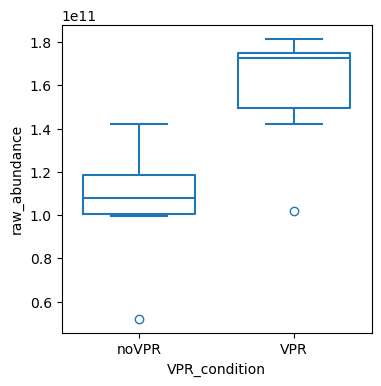

In [24]:
sc.pl.violin(adata, 'n_counts', groupby='VPR_condition')

sc.pl.violin(adata, 'raw_abundance', groupby='VPR_condition')

adata.obs['raw_abundance'] = np.sum(adata.layers['raw_counts_2'], axis=1).tolist()
sns.boxplot(data=adata.obs, x="VPR_condition", y="raw_abundance", order=['noVPR', 'VPR'], fill=False, gap=.1)

In [25]:
df = pd.DataFrame()
df['noVPR']=adata.obs['raw_abundance'][:6].tolist()
df['VPR']=adata.obs['raw_abundance'][6:].tolist()
df

,noVPR,VPR
0,1.126365e+11,1.421036e+11
1,1.421331e+11,1.719343e+11
2,5.218524e+10,1.020953e+11
3,1.031366e+11,1.756140e+11
4,9.980697e+10,1.733966e+11
5,1.206221e+11,1.816124e+11


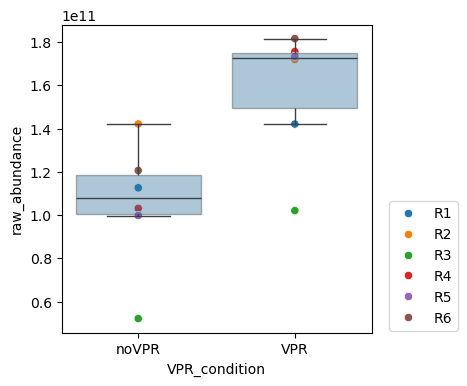

In [26]:
ax = sns.boxplot(data=adata.obs, x="VPR_condition", y="raw_abundance", order=['noVPR', 'VPR'],
                 showfliers=False, boxprops={'alpha': 0.4})
sns.scatterplot(data=adata.obs, x="VPR_condition", y="raw_abundance", hue='replicates',
              #hue_order=['R1', 'R2', 'R3', 'R4', 'R5', 'R6'],
              ax=ax)

plt.legend(bbox_to_anchor = [1.3, 0.45])
plt.savefig("boxplot_version1.png", bbox_inches='tight')
plt.show()

In [27]:
adata

AnnData object with n_obs × n_vars = 12 × 39620
    obs: 'VPR_condition', 'replicates', 'raw_abundance', 'n_counts'
    var: 'Annotated Sequence', 'Modifications', 'Qvality PEP', 'Qvality q-value', '# Protein Groups', '# Proteins', '# PSMs', 'Master Protein Accessions', 'Positions in Master Proteins', 'Modifications in Master Proteins', '# Missed Cleavages', 'Theo. MH+ [Da]', 'Abundance Ratio: (VPR) / (noVPR)', 'gene_name', 'n_samples', 'nb_peptides', 'nb_peptide_for_prot'
    uns: 'VPR_condition_colors'
    layers: 'raw_counts', 'raw_counts_2'

0.09674406865219586

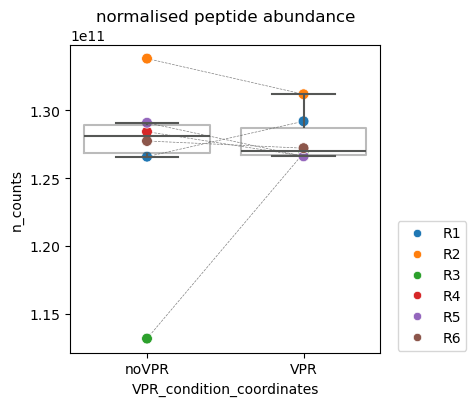

In [28]:
df_real = pd.DataFrame()
df_real['noVPR']=adata.obs[adata.obs['VPR_condition']=='noVPR']['n_counts'].tolist()
df_real['VPR']=adata.obs[adata.obs['VPR_condition']=='VPR']['n_counts'].tolist()

df_x_jitter = pd.DataFrame()
df_x_jitter['noVPR']= [0]*6
df_x_jitter['VPR']=[1]*6

adata.obs['VPR_condition_coordinates'] = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

ax = sns.scatterplot(data=adata.obs, x="VPR_condition_coordinates", y="n_counts", hue='replicates')

sns.boxplot(data=adata.obs, x="VPR_condition", y="n_counts", order=['noVPR', 'VPR'], fill=False, color="#555755",
                 #color="#dee0de", linecolor="#137"
                 showfliers=False, boxprops={'alpha': 0.4},)

ax.collections[0].set_sizes([60]) 
#for idx in df.index:
#    ax.plot(df.loc[idx,['noVPR','VPR']], df.loc[idx,['noVPR','VPR']], color = 'grey', linewidth = 0.5, linestyle = '--', zorder=-1)
for idx in df_real.index:
    ax.plot(df_x_jitter.loc[idx,['noVPR','VPR']], df_real.loc[idx,['noVPR','VPR']], color = 'grey', linewidth = 0.5, linestyle = '--', zorder=-1)
    #ax.plot(df_x_jitter.loc[idx,['condition 3','condition 4']], df.loc[idx,['condition 3','condition 4']], color = 'grey', linewidth = 0.5, linestyle = '--', zorder=-1)

plt.legend(bbox_to_anchor = [1.3, 0.45])
plt.title('normalised peptide abundance')
plt.savefig("boxplot_version_normalise.png", bbox_inches='tight', dpi=800)
plt.savefig("boxplot_version_normalise.pdf", bbox_inches='tight', dpi=800)
plt.savefig("boxplot_version_normalise.svg", bbox_inches='tight', dpi=800)
plt.show()

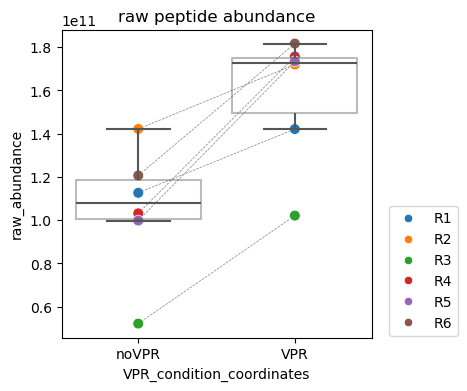

In [29]:
df_real = pd.DataFrame()
df_real['noVPR']=adata.obs[adata.obs['VPR_condition']=='noVPR']['raw_abundance'].tolist()
df_real['VPR']=adata.obs[adata.obs['VPR_condition']=='VPR']['raw_abundance'].tolist()

df_x_jitter = pd.DataFrame()
df_x_jitter['noVPR']= [0]*6
df_x_jitter['VPR']=[1]*6

adata.obs['VPR_condition_coordinates'] = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

ax = sns.scatterplot(data=adata.obs, x="VPR_condition_coordinates", y="raw_abundance", hue='replicates')

sns.boxplot(data=adata.obs, x="VPR_condition", y="raw_abundance", order=['noVPR', 'VPR'], fill=False, color="#555755",
                 #color="#dee0de", linecolor="#137"
                 showfliers=False, boxprops={'alpha': 0.4},)

ax.collections[0].set_sizes([60]) 
#for idx in df.index:
#    ax.plot(df.loc[idx,['noVPR','VPR']], df.loc[idx,['noVPR','VPR']], color = 'grey', linewidth = 0.5, linestyle = '--', zorder=-1)
for idx in df_real.index:
    ax.plot(df_x_jitter.loc[idx,['noVPR','VPR']], df_real.loc[idx,['noVPR','VPR']], color = 'grey', linewidth = 0.5, linestyle = '--', zorder=-1)
    #ax.plot(df_x_jitter.loc[idx,['condition 3','condition 4']], df.loc[idx,['condition 3','condition 4']], color = 'grey', linewidth = 0.5, linestyle = '--', zorder=-1)

plt.legend(bbox_to_anchor = [1.3, 0.45])
plt.title('raw peptide abundance')
plt.savefig("boxplot_version1.png", bbox_inches='tight', dpi=800)
plt.savefig("boxplot_version1.pdf", bbox_inches='tight', dpi=800)
plt.savefig("boxplot_version1.svg", bbox_inches='tight', dpi=800)
plt.show()

In [30]:
# Welch test
VPR_abundance = adata.obs['raw_abundance'][:6]
noVPR_abundance = adata.obs['raw_abundance'][6:]
stats.ttest_ind(VPR_abundance, noVPR_abundance)

TtestResult(statistic=np.float64(-3.013357115472979), pvalue=np.float64(0.013042603953712912), df=np.float64(10.0))

## THE FOLD CHANGE for each replicates! 

In [31]:
vpr_list = adata.obs['raw_abundance'][6:].tolist()
no_vpr_list = adata.obs['raw_abundance'][0:6].tolist()
vpr_ratio = [x/y for x,y in zip(vpr_list,no_vpr_list)]
vpr_ratio

[1.2616120753915765,
 1.2096715685865422,
 1.9564018548724438,
 1.7027326575178872,
 1.7373194582838292,
 1.5056311820651536]

In [32]:
# mean fold change
np.mean(vpr_ratio)

np.float64(1.5622281327862388)

In [33]:
np.log2(vpr_ratio)

array([0.33526837, 0.2746154 , 0.96820274, 0.76785194, 0.79686306,
       0.59036841])

# Rank peptide ratios

In [34]:
len(set(adata.var['Master Protein Accessions']))

4060

In [35]:
## Make the second plot - ratio VPR noVPR per peptide

In [36]:
adata_vpr = adata[adata.obs['VPR_condition']=='VPR',:].copy()
adata_novpr = adata[adata.obs['VPR_condition']=='noVPR',:].copy()

adata_vpr.var['sum']=np.sum(adata_vpr.layers['raw_counts_2'], axis=0).tolist()
adata_vpr.var['mean']=np.mean(adata_vpr.layers['raw_counts_2'], axis=0).tolist()
adata_vpr.var['std']=np.std(adata_vpr.layers['raw_counts_2'], axis=0).tolist()

adata_novpr.var['sum']=np.sum(adata_novpr.layers['raw_counts_2'], axis=0).tolist()
adata_novpr.var['mean']=np.mean(adata_novpr.layers['raw_counts_2'], axis=0).tolist()
adata_novpr.var['std']=np.std(adata_novpr.layers['raw_counts_2'], axis=0).tolist()

adata_novpr.var['no_vpr_count'] = np.sum(adata_novpr.layers['raw_counts_2'], axis=0).tolist()
adata_novpr_zero = adata_novpr[:,adata_novpr.var['no_vpr_count']==0]

adata_vpr.var['no_vpr_count'] = adata_novpr.var['no_vpr_count']

adata_novpr_nozero = adata_novpr[:,adata_novpr.var['no_vpr_count']!=0]
adata_novpr_nozero

adata_vpr_nozero = adata_vpr[:,adata_vpr.var['no_vpr_count']!=0]
adata_vpr_nozero

#vpr_list = adata_novpr_nozero.var['mean'].tolist()
#no_vpr_list = adata_novpr_nozero.var['mean'].tolist()

vpr_list = adata_vpr.var['sum'].tolist()
no_vpr_list = adata_novpr_nozero.var['sum'].tolist()

ratio_norm_peptide =[x/y for x,y in zip(vpr_list,no_vpr_list)]
adata_vpr_nozero.var['ratio_vpr_novpr'] = ratio_norm_peptide
#ratio_norm_peptide

df = adata_vpr_nozero.var.copy()
df = df.sort_values('ratio_vpr_novpr')
df['ranking'] = range(0,len(df['ratio_vpr_novpr'].tolist()))


/tmp/ipykernel_49360/2760835457.py:30: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_vpr_nozero.var['ratio_vpr_novpr'] = ratio_norm_peptide


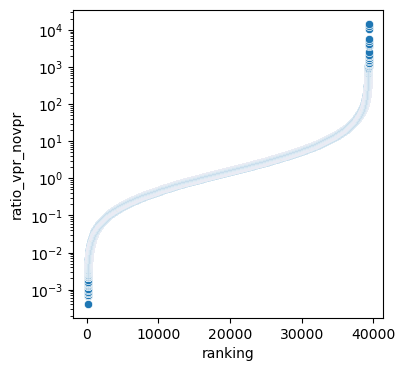

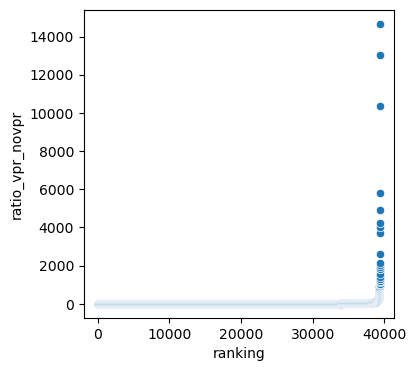

In [37]:
#peptide scatterplot
sns.scatterplot(df, x='ranking', y='ratio_vpr_novpr',)
plt.yscale('log')
plt.show()
#peptide scatterplot
sns.scatterplot(df, x='ranking', y='ratio_vpr_novpr',)
#plt.yscale('log')
plt.show()

# sum the 3 most abundant peptides per proteins

In [38]:
prt_list = []
prt_count = []
prt_sum = []
for protein in set(adata.var['Master Protein Accessions']):
    tmp_adata = adata[:,adata.var['Master Protein Accessions']==protein].copy()
    # Get the abundance of peptide
    top_coverage = np.sum(tmp_adata.X, axis=0).tolist()
    tmp_adata.var['filt_coverage']=top_coverage
    top_coverage.sort()
    #top_coverage

    if len(top_coverage)>3:
        tmp_adata=tmp_adata[:,tmp_adata.var['filt_coverage']>=top_coverage[-3]].copy()

    prt_count.append(np.mean(tmp_adata.X, axis=1).tolist())
    prt_sum.append(np.sum(tmp_adata.X, axis=1).tolist())
    prt_list.append(protein)
    
prt_count = np.array(prt_count).transpose()
prt_sum = np.array(prt_sum).transpose()
adata_prot = ad.AnnData(X=prt_sum)
adata_prot.obs = adata.obs.copy()
adata_prot.var_names = prt_list
adata_prot.layers['mean_peptides'] = prt_count

prt_count = np.array(prt_count)
prt_sum = np.array(prt_sum).transpose()

prt_list = []
prt_count = []
prt_sum = []
for protein in set(adata.var['Master Protein Accessions']):
    tmp_adata = adata[:,adata.var['Master Protein Accessions']==protein].copy()
    # Get the abundance of peptide
    top_coverage = np.sum(tmp_adata.X, axis=0).tolist()
    tmp_adata.var['filt_coverage']=top_coverage
    top_coverage.sort()
    #top_coverage

    if len(top_coverage)>3:
        tmp_adata=tmp_adata[:,tmp_adata.var['filt_coverage']>=top_coverage[-3]].copy()
    
    prt_count.append(np.mean(tmp_adata.layers['raw_counts_2'], axis=1).tolist())
    prt_sum.append(np.sum(tmp_adata.layers['raw_counts_2'], axis=1).tolist())
    prt_list.append(protein)
prt_count = np.array(prt_count).transpose()
prt_sum = np.array(prt_sum).transpose()
adata_prot.layers['raw_counts_2'] =prt_count
adata_prot.layers['sum_peptides_raw_counts_2'] = prt_sum

prt_list = []
prt_count = []
prt_sum = []
for protein in set(adata.var['Master Protein Accessions']):
    tmp_adata = adata[:,adata.var['Master Protein Accessions']==protein].copy()
    # Get the abundance of peptide
    top_coverage = np.sum(tmp_adata.X, axis=0).tolist()
    tmp_adata.var['filt_coverage']=top_coverage
    top_coverage.sort()
    #top_coverage

    if len(top_coverage)>3:
        tmp_adata=tmp_adata[:,tmp_adata.var['filt_coverage']>=top_coverage[-3]].copy()
    prt_count.append(np.mean(tmp_adata.layers['raw_counts'], axis=1).tolist())
    prt_sum.append(np.sum(tmp_adata.layers['raw_counts'], axis=1).tolist())
    prt_list.append(protein)
prt_count = np.array(prt_count).transpose()
prt_sum = np.array(prt_sum).transpose()
adata_prot.layers['raw_counts'] =prt_count
adata_prot.layers['sum_peptides_raw_counts'] = prt_sum

adata_prot

AnnData object with n_obs × n_vars = 12 × 4060
    obs: 'VPR_condition', 'replicates', 'raw_abundance', 'n_counts', 'VPR_condition_coordinates'
    layers: 'mean_peptides', 'raw_counts_2', 'sum_peptides_raw_counts_2', 'raw_counts', 'sum_peptides_raw_counts'

## Make the second plot - ratio VPR noVPR per protein

In [39]:
adata_vpr = adata_prot[adata_prot.obs['VPR_condition']=='VPR',:].copy()
adata_novpr = adata_prot[adata_prot.obs['VPR_condition']=='noVPR',:].copy()

adata_vpr.var['mean']=np.mean(adata_vpr.layers['raw_counts_2'], axis=0).tolist()
adata_vpr.var['std']=np.std(adata_vpr.layers['raw_counts_2'], axis=0).tolist()
adata_vpr.var['var']=np.var(adata_vpr.layers['raw_counts_2'], axis=0).tolist()

adata_novpr.var['mean']=np.mean(adata_novpr.layers['raw_counts_2'], axis=0).tolist()
adata_novpr.var['std']=np.std(adata_novpr.layers['raw_counts_2'], axis=0).tolist()
adata_novpr.var['var']=np.var(adata_novpr.layers['raw_counts_2'], axis=0).tolist()

adata_novpr.var['no_vpr_count'] = np.sum(adata_novpr.layers['raw_counts_2'], axis=0).tolist()
adata_novpr_zero = adata_novpr[:,adata_novpr.var['no_vpr_count']==0]

adata_vpr.var['no_vpr_count'] = adata_novpr.var['no_vpr_count']
adata_novpr_nozero = adata_novpr[:,adata_novpr.var['no_vpr_count']!=0]
adata_novpr_nozero

adata_vpr_nozero = adata_vpr[:,adata_vpr.var['no_vpr_count']!=0]
adata_vpr_nozero

vpr_list = adata_vpr_nozero.var['mean'].tolist()
no_vpr_list = adata_novpr_nozero.var['mean'].tolist()

ratio_norm_peptide =[x/y for x,y in zip(vpr_list,no_vpr_list)]
adata_vpr_nozero.var['ratio_vpr_novpr'] = ratio_norm_peptide
#ratio_norm_peptide

df = adata_vpr_nozero.var.copy()
df = df.sort_values('ratio_vpr_novpr')
df['ranking'] = range(0,len(df['ratio_vpr_novpr'].tolist()))


/tmp/ipykernel_49360/2510052149.py:26: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_vpr_nozero.var['ratio_vpr_novpr'] = ratio_norm_peptide


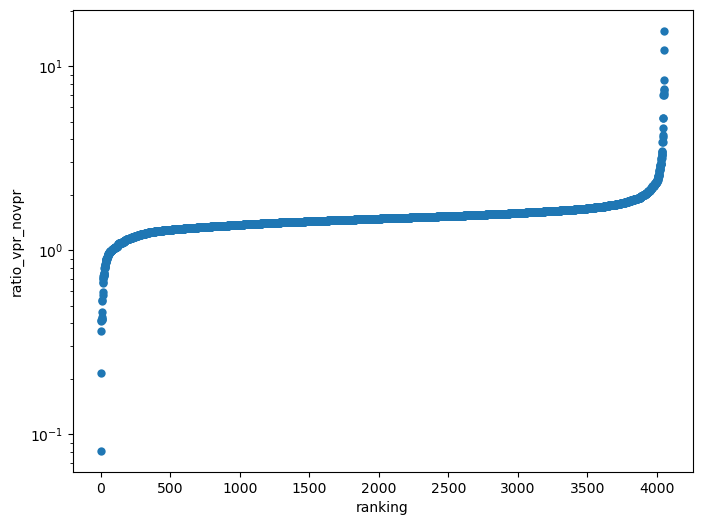

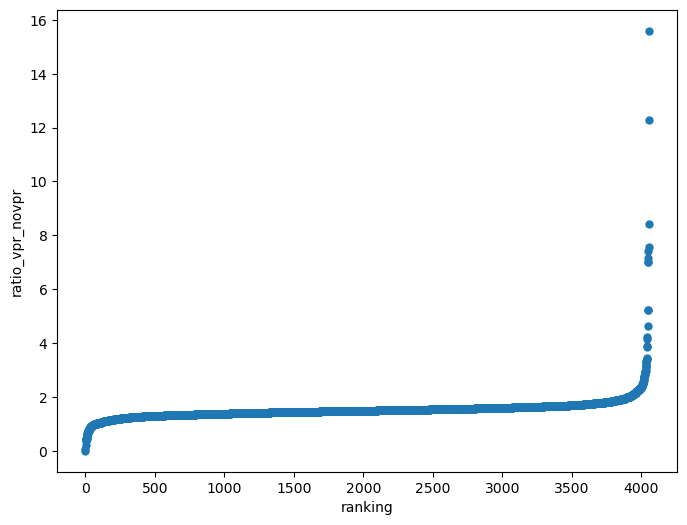

In [40]:
gene_name = []
missing_gene_names = []

for prot in df.index.tolist():
    
    if prot not in df_names.index.tolist():
        #print(prot)
        gene_name.append('missing protein name')
        missing_gene_names.append(prot)
    elif type(df_names.loc[prot]['gene name']) ==str:
        gene_name.append(df_names.loc[prot]['gene name'])
    else:
        gene_name.append(df_names.loc[prot]['gene name'].tolist()[0])
len(gene_name)
df['gene_name'] = gene_name

plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='ranking', y='ratio_vpr_novpr', linewidth=0)
plt.yscale('log')
plt.savefig("ranked_ratio_1_log.svg", bbox_inches='tight', dpi=800)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='ranking', y='ratio_vpr_novpr', linewidth=0)
plt.savefig("ranked_ratio_1_not_log.svg", bbox_inches='tight', dpi=800)
plt.show()

In [41]:
#df.to_csv('prot_abundance_ranked_ratios_Anna_mean_level_then_ratio_raw_counts.csv')
df_mean =pd.read_csv('prot_abundance_ranked_ratios_Anna_mean_level_then_ratio_raw_counts.csv')
df_mean['prot_id'] = df_mean['Unnamed: 0']
del df_mean['Unnamed: 0']
df_mean

,mean,std,var,no_vpr_count,ratio_vpr_novpr,ranking,gene_name,prot_id
0,0.000000e+00,0.000000e+00,0.000000e+00,1.665264e+06,0.000000,0,Ncs1,Q8BNY6
1,1.909676e+04,4.270166e+04,1.823432e+09,1.408608e+06,0.081343,1,Nle1,Q8VEJ4
2,1.057920e+06,2.013093e+05,4.052542e+10,2.960913e+07,0.214377,2,Acaca,Q5SWU9
3,1.012774e+05,1.545007e+05,2.387045e+10,1.671073e+06,0.363637,3,AU022252,Q5EBG8
4,6.143957e+04,1.373831e+05,1.887411e+10,8.953031e+05,0.411746,4,Krt19,P19001
...,...,...,...,...,...,...,...,...
4051,1.464769e+06,1.115003e+06,1.243231e+12,1.187520e+06,7.400812,4051,Cog4,Q8R1U1
4052,4.922813e+05,4.591067e+04,2.107790e+09,3.908515e+05,7.557058,4052,Irf3,P70671
4053,1.134956e+05,8.736711e+04,7.633012e+09,8.096927e+04,8.410272,4053,Pla2g12a,Q9EPR2
4054,4.361853e+05,2.067696e+05,4.275366e+10,2.133417e+05,12.267227,4054,Pdk2,Q9JK42


# plot all 6 replicates etc

In [42]:
array = adata_vpr_nozero.layers['raw_counts_2']/adata_novpr_nozero.layers['raw_counts_2']
df = pd.DataFrame(array)
df.columns = adata_vpr_nozero.var_names.tolist()

mean_ratios = []
std_ratios = []
nb_replicates = []
for column in df.columns.tolist():
    keep_value = []
    line = df[column].tolist()
    for element in line: 
        if np.isinf(element)==False and np.isnan(element)==False and element!=0:
            keep_value.append(element)
    mean_ratios.append(np.mean(keep_value))
    std_ratios.append(np.std(keep_value))
    nb_replicates.append(len(keep_value))


df = df.transpose()
df['std_of_ratio'] = std_ratios
df['mean_of_ratio'] = mean_ratios
df['nb_replicates_retained'] = nb_replicates


df=df[df['nb_replicates_retained']>2]
df

/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/views.py:151: RuntimeWarning: divide by zero encountered in divide
  results = super().__array_ufunc__(
/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/views.py:151: RuntimeWarning: invalid value encountered in divide
  results = super().__array_ufunc__(
/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dty

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained
Q9D0D5,1.780027,1.427197,inf,1.736141,2.053699,1.460433,0.229898,1.691500,5
Q60668,1.245445,1.150991,1.828688,1.626125,1.634614,1.456053,0.234535,1.490319,6
Q8VED9,1.167274,1.296858,6.294090,1.431241,1.523095,1.621723,1.826853,2.222380,6
Q62441,1.208754,0.938595,2.754722,1.433444,1.586705,1.272311,0.581924,1.532422,6
Q8BWW9,1.007581,1.142212,1.556612,2.067709,2.355058,1.469399,0.477552,1.599762,6
...,...,...,...,...,...,...,...,...,...
Q9CPX8,1.751065,1.350763,1.328674,1.761360,1.505170,4.872233,1.253773,2.094878,6
P17439,1.431087,1.244092,1.798055,1.802231,1.957596,1.695074,0.243000,1.654689,6
P14211,0.942693,1.192132,4.274963,1.744682,1.492890,1.573045,1.106748,1.870068,6
Q3UFS0,1.245852,1.450632,1.245995,1.473448,2.314502,1.243737,0.378863,1.495694,6


In [43]:
df_mean.index = df_mean['prot_id']
tmp_df = df_mean[['ranking', 'ratio_vpr_novpr', 'gene_name']]
df = df.merge(tmp_df, how='left', left_index=True, right_index=True)
#df = pd.concat([df, tmp_df], axis=1)
df = df.sort_values('mean_of_ratio')
df['ranking_mean_of_ratio'] = list(range(1,1+len(df['mean_of_ratio'].tolist())))
df

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio
Q8C569,0.299592,inf,0.312836,0.289542,inf,inf,0.009540,0.300657,3,24,0.748239,Fam118b,1
Q9CPX7,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699,0.345614,0.407085,6,8,0.424981,Mrps16,2
Q9CYL5,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708,0.196617,0.668626,6,15,0.661913,Glipr2,3
Q8R151,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502,0.230713,0.716954,6,18,0.705265,Znfx1,4
Q9JJA2,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388,0.293204,0.732017,6,17,0.701428,Cog8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q8BWZ3,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120,2.535981,7.292218,6,4048,7.016343,Naa25,4017
Q8R1U1,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542,7.893721,8.883751,6,4051,7.400812,Cog4,4018
Q9CQ40,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019
Q01065,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322,26.618642,12.724141,6,66,0.982159,Pde1b,4020


In [44]:
df2 = pd.DataFrame()
df2['ratio']=df[0]
df2 = df2.sort_values('ratio')
df2['ranking']=df['ranking'].tolist()
df2['prot']=df.index.tolist()
df2['sample']  = ['rep 1']*len(df2['ratio'].tolist())
df2['mean_of_ratio'] = df['mean_of_ratio'].tolist()
df2['std_of_ratio'] = df['std_of_ratio'].tolist()
df2['ranking_mean_of_ratio'] = df['ranking_mean_of_ratio'].tolist()

df3 = pd.DataFrame()
df3['ratio']=df[1]
df3['sample']  = ['rep 2']*len(df3['ratio'].tolist())
df3['ranking']=df['ranking'].tolist()
df3['prot']=df.index.tolist()
df3['mean_of_ratio'] = df['mean_of_ratio'].tolist()
df3['std_of_ratio'] = df['std_of_ratio'].tolist()
df3['ranking_mean_of_ratio'] = df['ranking_mean_of_ratio'].tolist()

result = pd.concat([df2, df3])
#result['prot'] = result.index.tolist()
result.index =  range(0,len(result['ratio'].tolist()))
#result


################

df3 = pd.DataFrame()
df3['ratio']=df[2]
#df3 = df3.sort_values('ratio')
df3['sample']  = ['rep 3']*len(df3['ratio'].tolist())
df3['ranking']=df['ranking'].tolist()
df3['prot']=df.index.tolist()
df3['mean_of_ratio'] = df['mean_of_ratio'].tolist()
df3['std_of_ratio'] = df['std_of_ratio'].tolist()
df3['ranking_mean_of_ratio'] = df['ranking_mean_of_ratio'].tolist()

result = pd.concat([result, df3])
#result['prot'] = result.index.tolist()
result.index =  range(0,len(result['ratio'].tolist()))
result

################

df3 = pd.DataFrame()
df3['ratio']=df[3]
#df3 = df3.sort_values('ratio')
#df3['ranking'] = df_mean['ranking'].tolist()
df3['sample']  = ['rep 4']*len(df3['ratio'].tolist())
df3['ranking']=df['ranking'].tolist()
df3['prot']=df.index.tolist()
df3['mean_of_ratio'] = df['mean_of_ratio'].tolist()
df3['std_of_ratio'] = df['std_of_ratio'].tolist()
df3['ranking_mean_of_ratio'] = df['ranking_mean_of_ratio'].tolist()

result = pd.concat([result, df3])
#result['prot'] = result.index.tolist()
result.index =  range(0,len(result['ratio'].tolist()))

################

df3 = pd.DataFrame()
df3['ratio']=df[4]
#df3 = df3.sort_values('ratio')
#df3['ranking'] = df_mean['ranking'].tolist()
df3['ranking']=df['ranking'].tolist()
df3['prot']=df.index.tolist()
df3['sample']  = ['rep 5']*len(df3['ratio'].tolist())
df3['mean_of_ratio'] = df['mean_of_ratio'].tolist()
df3['std_of_ratio'] = df['std_of_ratio'].tolist()
df3['ranking_mean_of_ratio'] = df['ranking_mean_of_ratio'].tolist()

result = pd.concat([result, df3])
#result['prot'] = result.index.tolist()
result.index =  range(0,len(result['ratio'].tolist()))

################

df3 = pd.DataFrame()
df3['ratio']=df[5]
#df3 = df3.sort_values('ratio')
#df3['ranking'] = df_mean['ranking'].tolist()
df3['sample']  = ['rep 6']*len(df3['ratio'].tolist())
df3['ranking']=df['ranking'].tolist()
df3['prot']=df.index.tolist()
df3['mean_of_ratio'] = df['mean_of_ratio'].tolist()
df3['std_of_ratio'] = df['std_of_ratio'].tolist()
df3['ranking_mean_of_ratio'] = df['ranking_mean_of_ratio'].tolist()

result = pd.concat([result, df3])
#result['prot'] = result.index.tolist()
result.index =  range(0,len(result['ratio'].tolist()))
result = result.sort_values(['ranking','sample'])
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


In [45]:
df

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio
Q8C569,0.299592,inf,0.312836,0.289542,inf,inf,0.009540,0.300657,3,24,0.748239,Fam118b,1
Q9CPX7,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699,0.345614,0.407085,6,8,0.424981,Mrps16,2
Q9CYL5,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708,0.196617,0.668626,6,15,0.661913,Glipr2,3
Q8R151,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502,0.230713,0.716954,6,18,0.705265,Znfx1,4
Q9JJA2,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388,0.293204,0.732017,6,17,0.701428,Cog8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q8BWZ3,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120,2.535981,7.292218,6,4048,7.016343,Naa25,4017
Q8R1U1,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542,7.893721,8.883751,6,4051,7.400812,Cog4,4018
Q9CQ40,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019
Q01065,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322,26.618642,12.724141,6,66,0.982159,Pde1b,4020


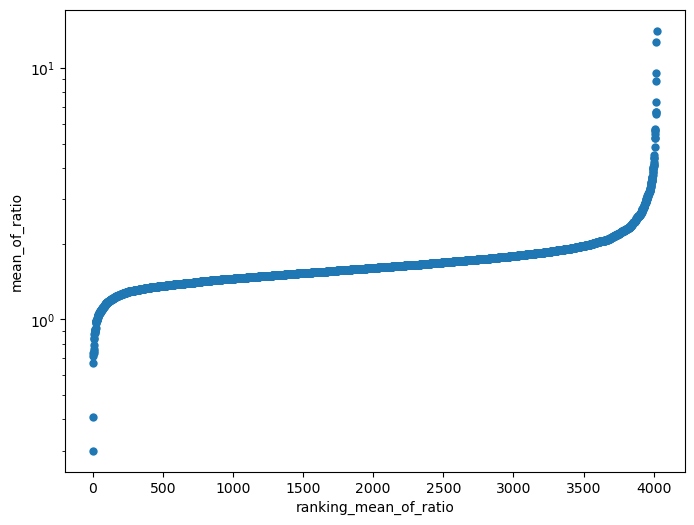

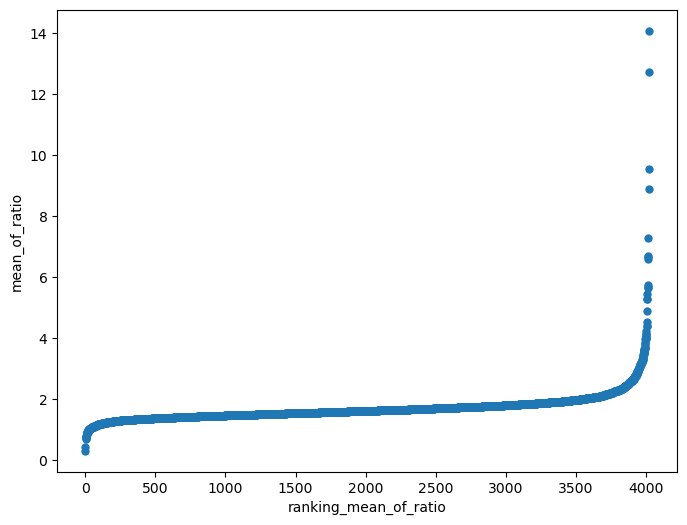

In [46]:
plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='ranking_mean_of_ratio', y='mean_of_ratio', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
plt.yscale('log')

plt.savefig("ranked_ratio_2_log.svg", bbox_inches='tight', dpi=800)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='ranking_mean_of_ratio', y='mean_of_ratio', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
#plt.yscale('log')
plt.savefig("ranked_ratio_2_not_log.svg", bbox_inches='tight', dpi=800)
plt.show()

In [47]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


In [66]:
df

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio
Q8C569,0.299592,inf,0.312836,0.289542,inf,inf,0.009540,0.300657,3,24,0.748239,Fam118b,1
Q9CPX7,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699,0.345614,0.407085,6,8,0.424981,Mrps16,2
Q9CYL5,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708,0.196617,0.668626,6,15,0.661913,Glipr2,3
Q8R151,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502,0.230713,0.716954,6,18,0.705265,Znfx1,4
Q9JJA2,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388,0.293204,0.732017,6,17,0.701428,Cog8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q8BWZ3,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120,2.535981,7.292218,6,4048,7.016343,Naa25,4017
Q8R1U1,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542,7.893721,8.883751,6,4051,7.400812,Cog4,4018
Q9CQ40,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019
Q01065,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322,26.618642,12.724141,6,66,0.982159,Pde1b,4020


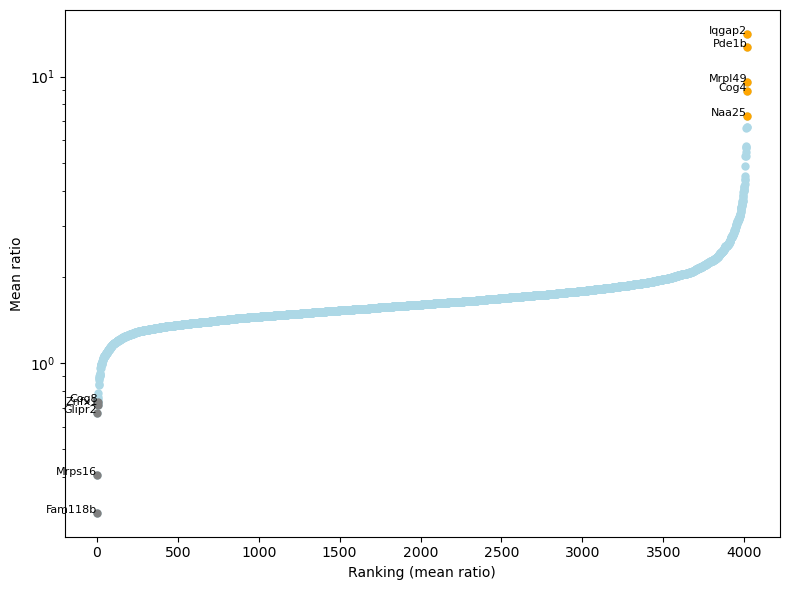

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by mean_of_ratio
#df_sorted = result.sort_values('mean_of_ratio', ascending=False)
df_sorted = df.sort_values('mean_of_ratio', ascending=False)

# Select top 20 and bottom 5
top20 = df_sorted.head(5)
bottom5 = df_sorted.tail(5)

plt.figure(figsize=(8, 6))

# Plot all points in light grey (background)
sns.scatterplot(
    data=df,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='lightblue',
    linewidth=0
)

# Overlay top 20 in orange
sns.scatterplot(
    data=top20,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='orange',
    linewidth=0
)

# Overlay bottom 5 in grey (darker)
sns.scatterplot(
    data=bottom5,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='grey',
    linewidth=0
)

# Annotate protein names for top 20
for _, row in top20.iterrows():
    plt.text(
        row['ranking_mean_of_ratio'],
        row['mean_of_ratio'],
        row['gene_name'],
        fontsize=8,
        ha='right'
    )

# Annotate protein names for bottom 5
for _, row in bottom5.iterrows():
    plt.text(
        row['ranking_mean_of_ratio'],
        row['mean_of_ratio'],
        row['gene_name'],
        fontsize=8,
        ha='right'
    )

plt.xlabel("Ranking (mean ratio)")
plt.ylabel("Mean ratio")
plt.yscale('log')
plt.tight_layout()
plt.savefig("ranked_ratio_log.svg", bbox_inches='tight', dpi=800)
plt.show()


# Plot for paper resubmission

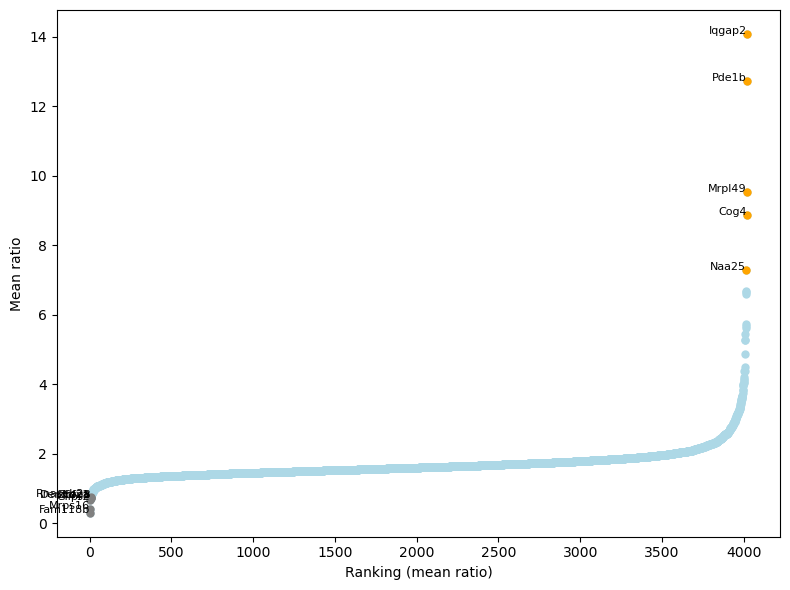

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by mean_of_ratio
#df_sorted = result.sort_values('mean_of_ratio', ascending=False)
df_sorted = df.sort_values('mean_of_ratio', ascending=False)

# Select top 20 and bottom 5
top20 = df_sorted.head(5)
bottom5 = df_sorted.tail(7)

plt.figure(figsize=(8, 6))

# Plot all points in light grey (background)
sns.scatterplot(
    data=df,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='lightblue',
    linewidth=0
)

# Overlay top 20 in orange
sns.scatterplot(
    data=top20,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='orange',
    linewidth=0
)

# Overlay bottom 5 in grey (darker)
sns.scatterplot(
    data=bottom5,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='grey',
    linewidth=0
)

# Annotate protein names for top 20
for _, row in top20.iterrows():
    plt.text(
        row['ranking_mean_of_ratio'],
        row['mean_of_ratio'],
        row['gene_name'],
        fontsize=8,
        ha='right'
    )

# Annotate protein names for bottom 5
for _, row in bottom5.iterrows():
    plt.text(
        row['ranking_mean_of_ratio'],
        row['mean_of_ratio'],
        row['gene_name'],
        fontsize=8,
        ha='right'
    )

plt.xlabel("Ranking (mean ratio)")
plt.ylabel("Mean ratio")
#plt.yscale('log')
plt.tight_layout()
plt.savefig("ranked_ratio_not_log.svg", bbox_inches='tight', dpi=800)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by mean_of_ratio
#df_sorted = result.sort_values('mean_of_ratio', ascending=False)
df_sorted = df.sort_values('mean_of_ratio', ascending=False)

# Select top 20 and bottom 5
top20 = df_sorted.head(5)
bottom5 = df_sorted.tail(7)

plt.figure(figsize=(8, 6))

# Plot all points in light grey (background)
sns.scatterplot(
    data=df,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='lightblue',
    linewidth=0
)

# Overlay top 20 in orange
sns.scatterplot(
    data=top20,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='orange',
    linewidth=0
)

# Overlay bottom 5 in grey (darker)
sns.scatterplot(
    data=bottom5,
    x='ranking_mean_of_ratio',
    y='mean_of_ratio',
    color='grey',
    linewidth=0
)

# Annotate protein names for top 20
for _, row in top20.iterrows():
    plt.text(
        row['ranking_mean_of_ratio'],
        row['mean_of_ratio'],
        row['gene_name'],
        fontsize=8,
        ha='right'
    )

# Annotate protein names for bottom 5
for _, row in bottom5.iterrows():
    plt.text(
        row['ranking_mean_of_ratio'],
        row['mean_of_ratio'],
        row['gene_name'],
        fontsize=8,
        ha='right'
    )

plt.xlabel("Ranking (mean ratio)")
plt.ylabel("Mean ratio")
#plt.yscale('log')
plt.tight_layout()
plt.savefig("ranked_ratio_not_log.svg", bbox_inches='tight', dpi=800)
plt.show()


In [69]:
df

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio
Q8C569,0.299592,inf,0.312836,0.289542,inf,inf,0.009540,0.300657,3,24,0.748239,Fam118b,1
Q9CPX7,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699,0.345614,0.407085,6,8,0.424981,Mrps16,2
Q9CYL5,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708,0.196617,0.668626,6,15,0.661913,Glipr2,3
Q8R151,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502,0.230713,0.716954,6,18,0.705265,Znfx1,4
Q9JJA2,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388,0.293204,0.732017,6,17,0.701428,Cog8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q8BWZ3,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120,2.535981,7.292218,6,4048,7.016343,Naa25,4017
Q8R1U1,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542,7.893721,8.883751,6,4051,7.400812,Cog4,4018
Q9CQ40,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019
Q01065,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322,26.618642,12.724141,6,66,0.982159,Pde1b,4020


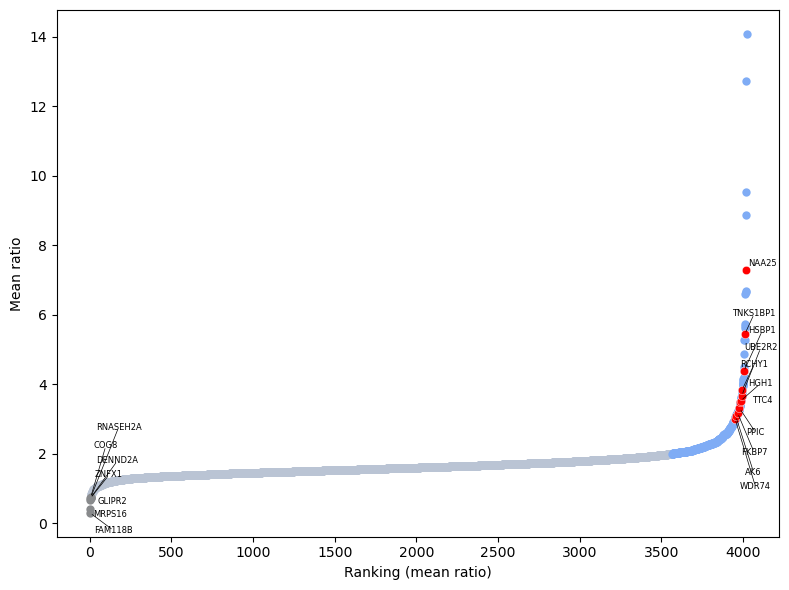

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
# List of proteins to highlight
highlight_proteins = ["Naa25", "Tnks1bp1", "Hsbp1",
                     'Ube2r2', "Rchy1", "Hgh1",
                     'Ak6', 'Ttc4', "Ppic",
                     'Wdr74', 'Fkbp7', ]  # replace with your list

# Create color category
df["color"] = "blue"
df.loc[df["mean_of_ratio"] < 0.75, "color"] = "grey"
df.loc[df["mean_of_ratio"] > 2, "color"] = "orange"
df.loc[df["gene_name"].isin(highlight_proteins), "color"] = "red"

plt.figure(figsize=(8, 6))

# Plot order controls what appears on top
sns.scatterplot(data=df[df["color"] == "blue"],
                x='ranking_mean_of_ratio', y='mean_of_ratio',
                color='#bac4d4', linewidth=0)

sns.scatterplot(data=df[df["color"] == "grey"],
                x='ranking_mean_of_ratio', y='mean_of_ratio',
                color='#888a8c', linewidth=0)

sns.scatterplot(data=df[df["color"] == "orange"],
                x='ranking_mean_of_ratio', y='mean_of_ratio',
                color='#7facf5', linewidth=0)

# Plot red LAST so it appears on top
sns.scatterplot(data=df[df["color"] == "red"],
                x='ranking_mean_of_ratio', y='mean_of_ratio',
                color='red', edgecolor="white", linewidth=0.3)

# Create list for text objects
texts = []

label_df = df[
    (df["gene_name"].isin(highlight_proteins)) |
    (df["mean_of_ratio"] < 0.75)
].drop_duplicates(subset="gene_name")

for _, row in label_df.iterrows():
    texts.append(
        plt.text(
            row['ranking_mean_of_ratio'],
            row['mean_of_ratio'],
            row['gene_name'].upper(),
            fontsize=6
        )
    )

adjust_text(
    texts,
    only_move={'points':'y', 'text':'y'},
    force_text=3,
    force_points=2,
    expand_text=(2.5, 2.5),
    expand_points=(3, 3),
    lim=2000,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5)
)
plt.xlabel("Ranking (mean ratio)")
plt.ylabel("Mean ratio")

plt.tight_layout()
plt.savefig("ranked_ratio_not_log.svg", bbox_inches='tight', dpi=800)
plt.show()

In [76]:
df_sorted.to_csv('prot_data_to_match_to_riboseq.csv')

In [ ]:
df_sorted.to_csv('prot_data_to_match_to_riboseq.csv')

In [65]:
df_sorted['ratio R1']=df_sorted[0].tolist()
df_sorted['ratio R2']=df_sorted[1].tolist()
df_sorted['ratio R3']=df_sorted[2].tolist()
df_sorted['ratio R4']=df_sorted[3].tolist()
df_sorted['ratio R5']=df_sorted[4].tolist()
df_sorted['ratio R6']=df_sorted[5].tolist()
del df_sorted[0], df_sorted[1], df_sorted[2], df_sorted[3], df_sorted[4], df_sorted[5], 

In [66]:
df_sorted.columns

Index(['std_of_ratio', 'mean_of_ratio', 'nb_replicates_retained', 'ranking',
       'ratio_vpr_novpr', 'gene_name', 'ranking_mean_of_ratio', 'ratio R1',
       'ratio R2', 'ratio R3', 'ratio R4', 'ratio R5', 'ratio R6'],
      dtype='object')

In [83]:
df_sorted

,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio,ratio R1,ratio R2,ratio R3,ratio R4,ratio R5,ratio R6
Q3UQ44,18.238542,14.086026,6,3991,2.323045,Iqgap2,4021,37.345203,1.587384,1.668997,1.645124,42.233707,0.035739
Q01065,26.618642,12.724141,6,66,0.982159,Pde1b,4020,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322
Q9CQ40,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125
Q8R1U1,7.893721,8.883751,6,4051,7.400812,Cog4,4018,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542
Q8BWZ3,2.535981,7.292218,6,4048,7.016343,Naa25,4017,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9JJA2,0.293204,0.732017,6,17,0.701428,Cog8,5,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388
Q8R151,0.230713,0.716954,6,18,0.705265,Znfx1,4,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502
Q9CYL5,0.196617,0.668626,6,15,0.661913,Glipr2,3,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708
Q9CPX7,0.345614,0.407085,6,8,0.424981,Mrps16,2,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699


In [82]:
df_sorted

,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio,ratio R1,ratio R2,ratio R3,ratio R4,ratio R5,ratio R6
Q3UQ44,18.238542,14.086026,6,3991,2.323045,Iqgap2,4021,37.345203,1.587384,1.668997,1.645124,42.233707,0.035739
Q01065,26.618642,12.724141,6,66,0.982159,Pde1b,4020,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322
Q9CQ40,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125
Q8R1U1,7.893721,8.883751,6,4051,7.400812,Cog4,4018,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542
Q8BWZ3,2.535981,7.292218,6,4048,7.016343,Naa25,4017,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9JJA2,0.293204,0.732017,6,17,0.701428,Cog8,5,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388
Q8R151,0.230713,0.716954,6,18,0.705265,Znfx1,4,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502
Q9CYL5,0.196617,0.668626,6,15,0.661913,Glipr2,3,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708
Q9CPX7,0.345614,0.407085,6,8,0.424981,Mrps16,2,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699


In [68]:
df_sorted.to_csv('suppl_table_proteomic.csv')

In [80]:
df_sorted[df_sorted['mean_of_ratio']<0.75].shape

(7, 13)

In [88]:
print(df_sorted[df_sorted['mean_of_ratio']<=0.75]['gene_name'].tolist())

['Rnaseh2a', 'Dennd2a', 'Cog8', 'Znfx1', 'Glipr2', 'Mrps16', 'Fam118b']


In [87]:
df_sorted[df_sorted['mean_of_ratio']<1].shape

(30, 13)

In [58]:
df_sorted[df_sorted['mean_of_ratio']>1.25]

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio
Q3UQ44,37.345203,1.587384,1.668997,1.645124,42.233707,0.035739,18.238542,14.086026,6,3991,2.323045,Iqgap2,4021
Q01065,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322,26.618642,12.724141,6,66,0.982159,Pde1b,4020
Q9CQ40,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019
Q8R1U1,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542,7.893721,8.883751,6,4051,7.400812,Cog4,4018
Q8BWZ3,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120,2.535981,7.292218,6,4048,7.016343,Naa25,4017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
P15864,1.047334,1.053731,0.941148,1.699974,1.476842,1.306630,0.268333,1.254276,6,324,1.238440,H1f2,195
Q99LG4,0.926984,0.601857,1.766937,1.512790,1.491521,1.219500,0.391559,1.253265,6,220,1.170321,Ttc5,194
P23506,1.346324,1.137141,2.130073,0.750985,1.492039,0.652261,0.493529,1.251470,6,120,1.059955,Pcmt1,193
Q61301,0.794373,1.157691,1.078875,1.523481,1.702251,1.249175,0.295725,1.250974,6,307,1.225351,Ctnna2,192


In [59]:
df_sorted

,0,1,2,3,4,5,std_of_ratio,mean_of_ratio,nb_replicates_retained,ranking,ratio_vpr_novpr,gene_name,ranking_mean_of_ratio
Q3UQ44,37.345203,1.587384,1.668997,1.645124,42.233707,0.035739,18.238542,14.086026,6,3991,2.323045,Iqgap2,4021
Q01065,0.563108,0.676586,72.244235,0.989754,0.917841,0.953322,26.618642,12.724141,6,66,0.982159,Pde1b,4020
Q9CQ40,1.366928,1.082842,50.057086,1.420497,1.619592,1.702125,18.120193,9.541512,6,3114,1.610449,Mrpl49,4019
Q8R1U1,11.393108,1.876927,1.286633,6.940792,24.803503,7.001542,7.893721,8.883751,6,4051,7.400812,Cog4,4018
Q8BWZ3,5.599807,8.418576,2.609290,10.533333,8.340180,8.252120,2.535981,7.292218,6,4048,7.016343,Naa25,4017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9JJA2,1.080554,0.522833,0.543091,0.521122,1.206114,0.518388,0.293204,0.732017,6,17,0.701428,Cog8,5
Q8R151,1.028258,0.455066,0.908373,0.575431,0.882094,0.452502,0.230713,0.716954,6,18,0.705265,Znfx1,4
Q9CYL5,0.987182,0.461140,0.853885,0.512095,0.695747,0.501708,0.196617,0.668626,6,15,0.661913,Glipr2,3
Q9CPX7,0.070183,0.549266,0.056160,0.821311,0.098892,0.846699,0.345614,0.407085,6,8,0.424981,Mrps16,2


In [60]:
3831/4021

0.9527480726187516

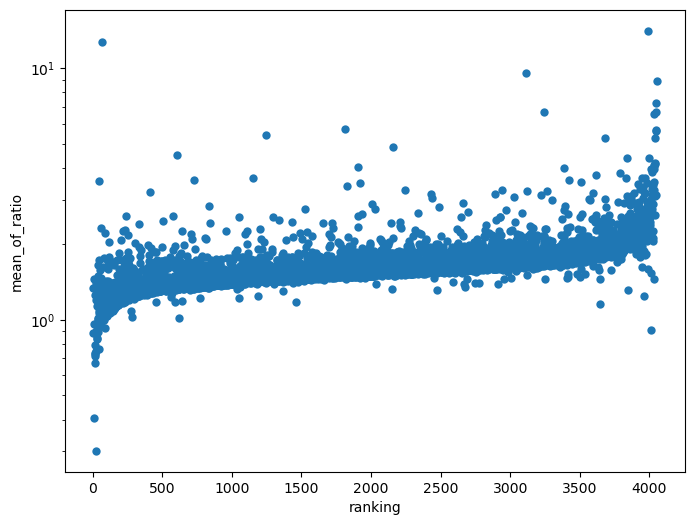

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='ranking', y='mean_of_ratio', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
plt.yscale('log')

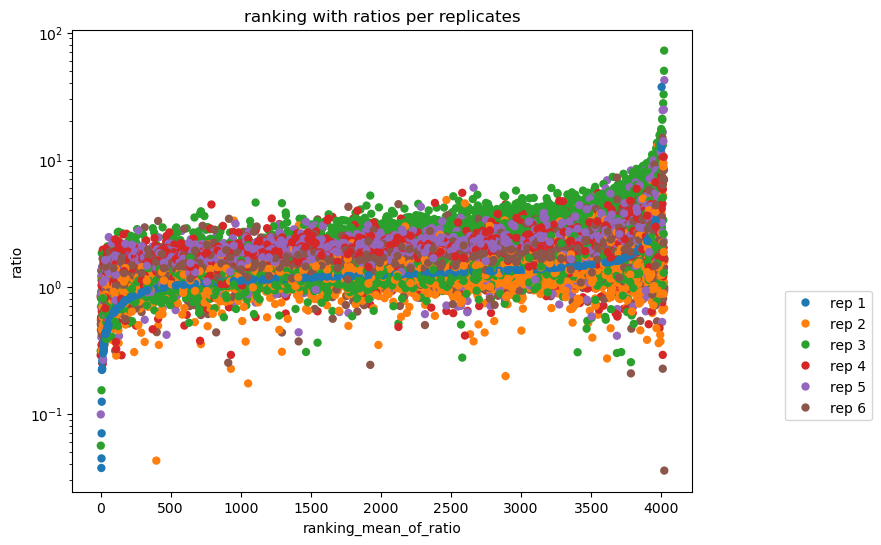

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(result, x='ranking_mean_of_ratio', y='ratio', hue='sample', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
plt.yscale('log')


plt.legend(bbox_to_anchor = [1.3, 0.45])
plt.title('ranking with ratios per replicates')
plt.savefig("ranking_per_replicate.svg", bbox_inches='tight', dpi=800)


In [51]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


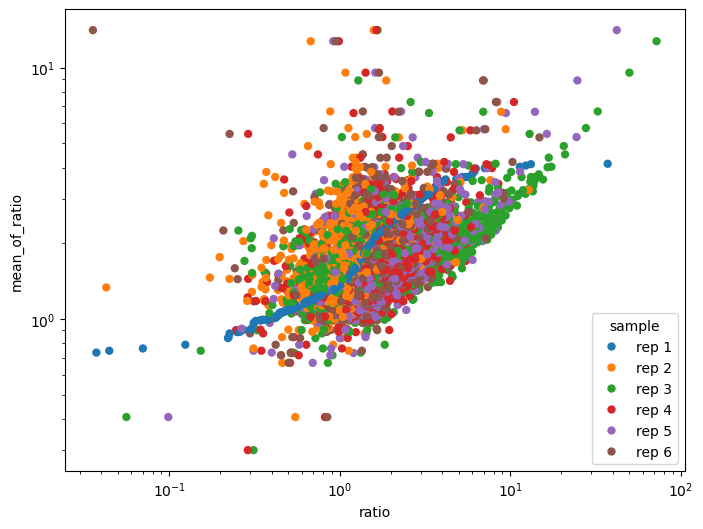

In [52]:
plt.figure(figsize=(8, 6))
sns.scatterplot(result, x='ratio', y='mean_of_ratio', hue='sample', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
plt.yscale('log')
plt.xscale('log')

<Axes: xlabel='ratio', ylabel='mean_of_ratio'>

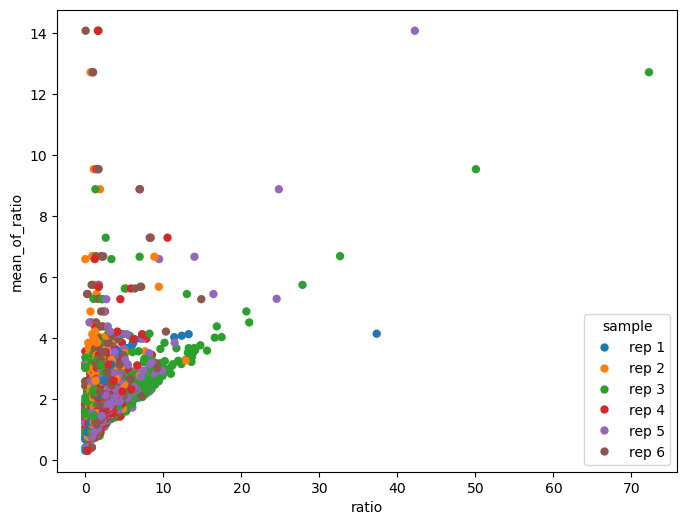

In [53]:
plt.figure(figsize=(8, 6))
sns.scatterplot(result, x='ratio', y='mean_of_ratio', hue='sample', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
#plt.yscale('log')
#plt.xscale('log')

In [54]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


<Axes: xlabel='std_of_ratio', ylabel='mean_of_ratio'>

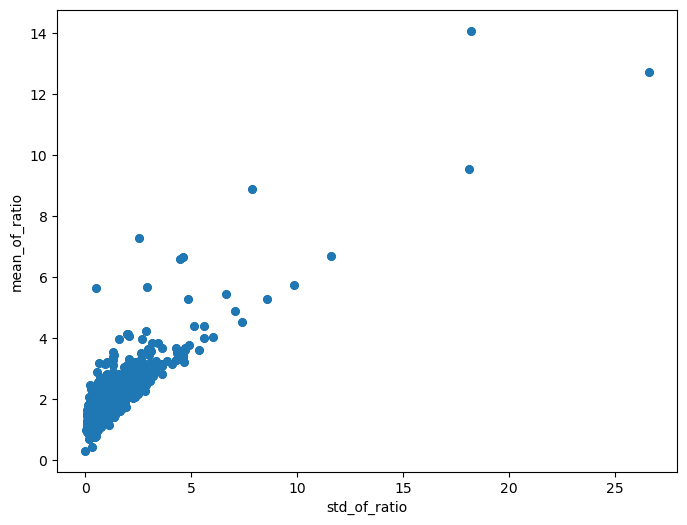

In [55]:
plt.figure(figsize=(8, 6))

sns.scatterplot(result, x='std_of_ratio', y='mean_of_ratio', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
#plt.yscale('log')
#plt.xscale('log')

In [56]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


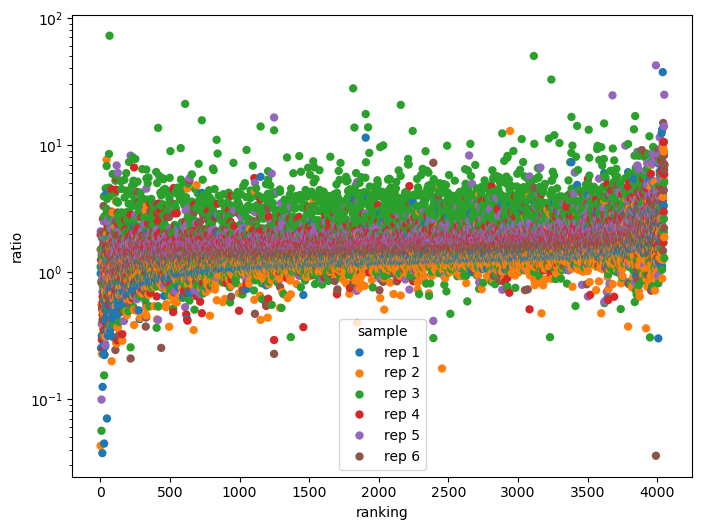

In [65]:
plt.figure(figsize=(8, 6))
sns.scatterplot(result, x='ranking', y='ratio', hue='sample', linewidth=0)
#sns.scatterplot(df, x='ranking', y='std',)
plt.yscale('log')

<Axes: xlabel='ranking', ylabel='ratio'>

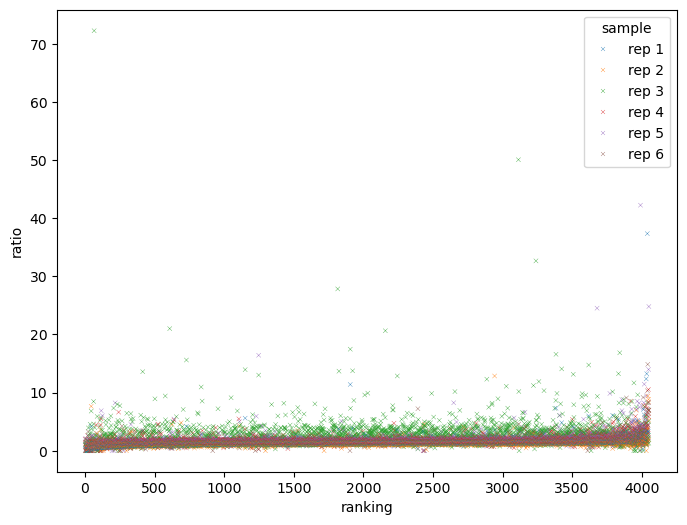

In [66]:
plt.figure(figsize=(8, 6))
#sns.scatterplot(result, x='ranking', y='ratio', hue='sample', linewidth=0)
sns.scatterplot(result, x='ranking', y='ratio', hue='sample', marker='x', s=10)
#sns.scatterplot(df, x='ranking', y='std',)
#plt.yscale('log')

In [67]:
df.to_csv('final_proteomic_ranking_2_options_sum_top3_peptides.csv')

/store24/project24/ladcol_002/miniconda3/envs/scanpy/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


KeyboardInterrupt: 


KeyboardInterrupt



<Figure size 1700x600 with 0 Axes>

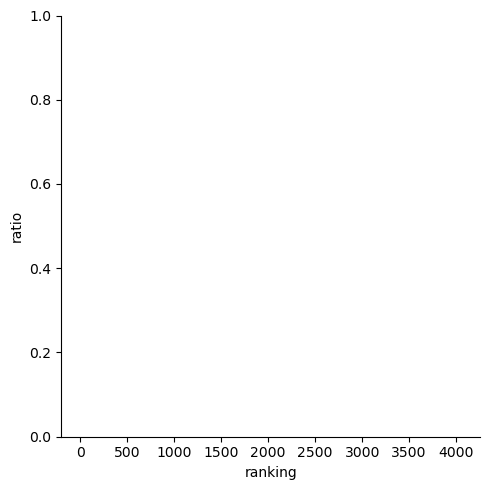

In [68]:
plt.figure(figsize=(17, 6))
sns.lmplot(result, x='ranking', y='ratio', x_estimator=np.mean,  line_kws=dict(color='C1'), hue='sample')
plt.yscale('log')

In [ ]:
dict_param = {}
dict_param['color']='C1'
dict_param['s']=10

In [ ]:
plt.figure(figsize=(17, 6))
sns.lmplot(result, x='ranking', y='ratio', x_estimator=np.mean)
plt.yscale('log')

In [ ]:
result

In [ ]:
df.loc['O55201'] #Supt5h

In [ ]:
df.sort_values('ratio_vpr_novpr')

In [ ]:

plt.figure(figsize=(17, 6))
sns.lmplot(result, x='ranking_mean_of_ratio', y='ratio', x_estimator=np.mean)
plt.yscale('log')

In [ ]:
plt.figure(figsize=(17, 6))
sns.regplot(result, x='ranking_mean_of_ratio', y='ratio',
            x_estimator=np.mean, order=2,
            marker='x', color='.3', ci=99, line_kws=dict(color='r'))
plt.yscale('log')

In [ ]:
plt.figure(figsize=(17, 6))
sns.regplot(result, x='ranking_mean_of_ratio', y='ratio',
            marker='x', color='.3', ci=99, line_kws=dict(color='r'))
plt.yscale('log')



In [ ]:
result

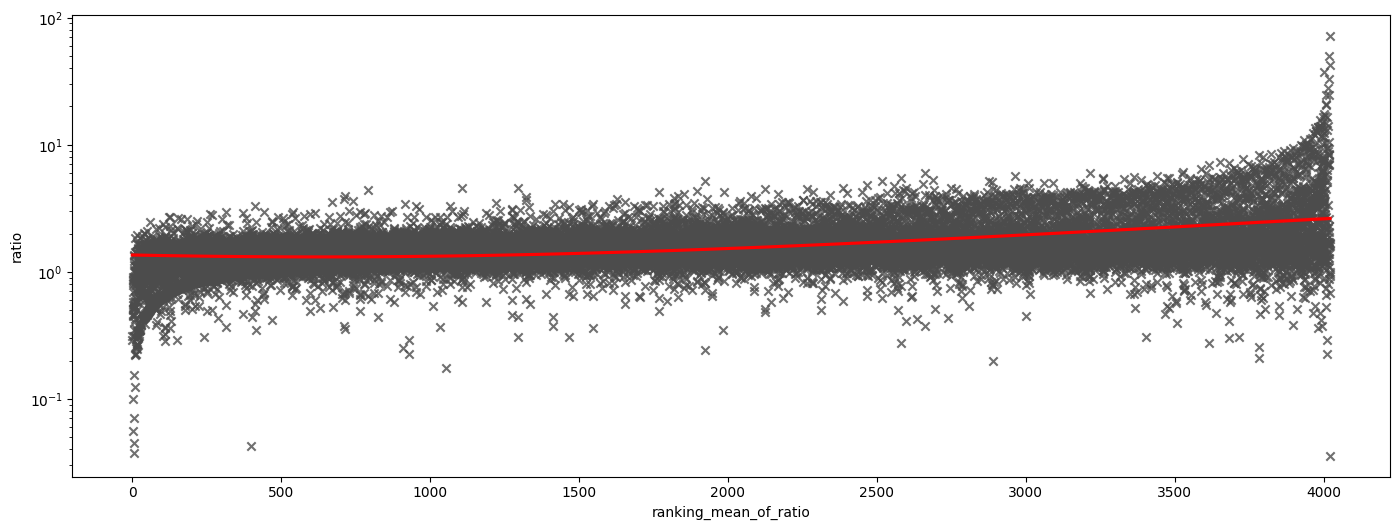

In [66]:
index =0
tmp_ratio = []
tmp_ranking = []
for line in result['ratio'].tolist():
    if (np.isnan(line) == False) and (line < np.inf):
        tmp_ratio.append(line)
        tmp_ranking.append(result['ranking_mean_of_ratio'].tolist()[index])
    index += 1

tmp_results = pd.DataFrame()
tmp_results['ratio']=tmp_ratio
tmp_results['ranking_mean_of_ratio']=tmp_ranking

plt.figure(figsize=(17, 6))
sns.regplot(tmp_results, x='ranking_mean_of_ratio', y='ratio', order=2, #ci=99,
            marker='x', color='.3', line_kws=dict(color='r'))
plt.yscale('log')

<Figure size 1700x600 with 0 Axes>

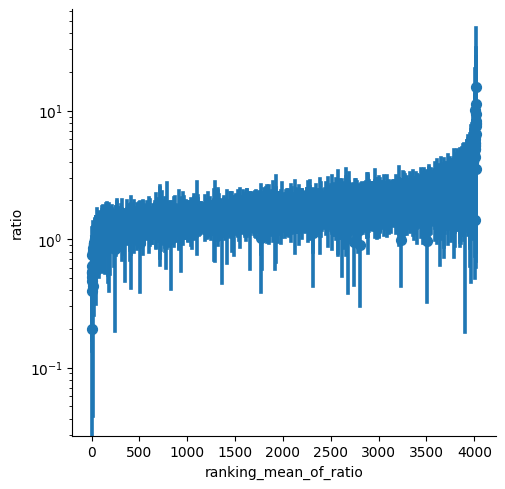

In [67]:
plt.figure(figsize=(17, 6))
sns.lmplot(tmp_results, x='ranking_mean_of_ratio', y='ratio', x_estimator=np.mean)
plt.yscale('log')

In [ ]:
index =0
tmp_ratio = []
tmp_ranking = []
for line in result['ratio'].tolist():
    if (np.isnan(line) == False) and (line < np.inf):
        tmp_ratio.append(line)
        tmp_ranking.append(result['ranking'].tolist()[index])
    index += 1

tmp_results = pd.DataFrame()
tmp_results['ratio']=tmp_ratio
tmp_results['ranking']=tmp_ranking

plt.figure(figsize=(17, 6))
sns.regplot(tmp_results, x='ranking', y='ratio', order=2, #ci=99,
            marker='x', color='.3', line_kws=dict(color='r'))
plt.yscale('log')

In [ ]:
plt.figure(figsize=(17, 6))
sns.lmplot(tmp_results, x='ranking', y='ratio', x_estimator=np.mean)
plt.yscale('log')

In [ ]:
plt.figure(figsize=(17, 6))
sns.regplot(result, x='ranking', y='ratio', order=2,
            marker='x', color='.3', line_kws=dict(color='r'))
plt.yscale('log')

In [ ]:
plt.figure(figsize=(17, 6))
sns.regplot(result, x='ranking', y='ratio',
            x_estimator=np.mean, order=2,
            marker='x', color='.3', ci=99, line_kws=dict(color='r'))
plt.yscale('log')

In [71]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


In [57]:

# importing required packages
import seaborn as sns
import matplotlib.pyplot as plt
 
# loading dataset
data = sns.load_dataset("mpg")
 
# draw regplot
sns.regplot(x = "ranking_mean_of_ratio", order=2,
            y = "ratio", marker='x', color='.3', ci=99,
            data = result, line_kws=dict(color='r'))
 
# show the plot
plt.show()

URLError: <urlopen error [Errno 101] Network is unreachable>

In [ ]:
data

In [ ]:
sns.scatterplot(df, x='ratio_vpr_novpr', y='std_of_ratio', linewidth=0)

In [ ]:
sns.scatterplot(df_mean, x='ratio_vpr_novpr', y='std', linewidth=0)
#plt.xscale('log')
#plt.xscale('log')

In [ ]:
sns.scatterplot(df, x='ratio_vpr_novpr', y='std_of_ratio')
plt.xscale('log')
plt.yscale('log')

In [ ]:
sns.scatterplot(df_mean, x='ratio_vpr_novpr', y='std',)
plt.xscale('log')
plt.yscale('log')

In [ ]:
df_mean

In [ ]:
sns.scatterplot(df_mean, x='mean', y='var',)
plt.xscale('log')

In [ ]:
df

In [ ]:
# Use plotly 

In [47]:
import plotly.graph_objs as go
import pandas as pd
#!pip install plotly

import plotly.io as pio
pio.renderers.default = 'notebook'

import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

#df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/wind_speed_laurel_nebraska.csv')



ModuleNotFoundError: No module named 'plotly'

In [130]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
397,0.969480,2,Q5SWU9,rep 1,1.334229,0.672416,398
4418,0.042814,2,Q5SWU9,rep 2,1.334229,0.672416,398
8439,1.091801,2,Q5SWU9,rep 3,1.334229,0.672416,398
12460,1.959392,2,Q5SWU9,rep 4,1.334229,0.672416,398
16481,2.087367,2,Q5SWU9,rep 5,1.334229,0.672416,398
...,...,...,...,...,...,...,...
8038,1.876927,4051,Q8R1U1,rep 2,8.883751,7.893721,4018
12059,1.286633,4051,Q8R1U1,rep 3,8.883751,7.893721,4018
16080,6.940792,4051,Q8R1U1,rep 4,8.883751,7.893721,4018
20101,24.803503,4051,Q8R1U1,rep 5,8.883751,7.893721,4018


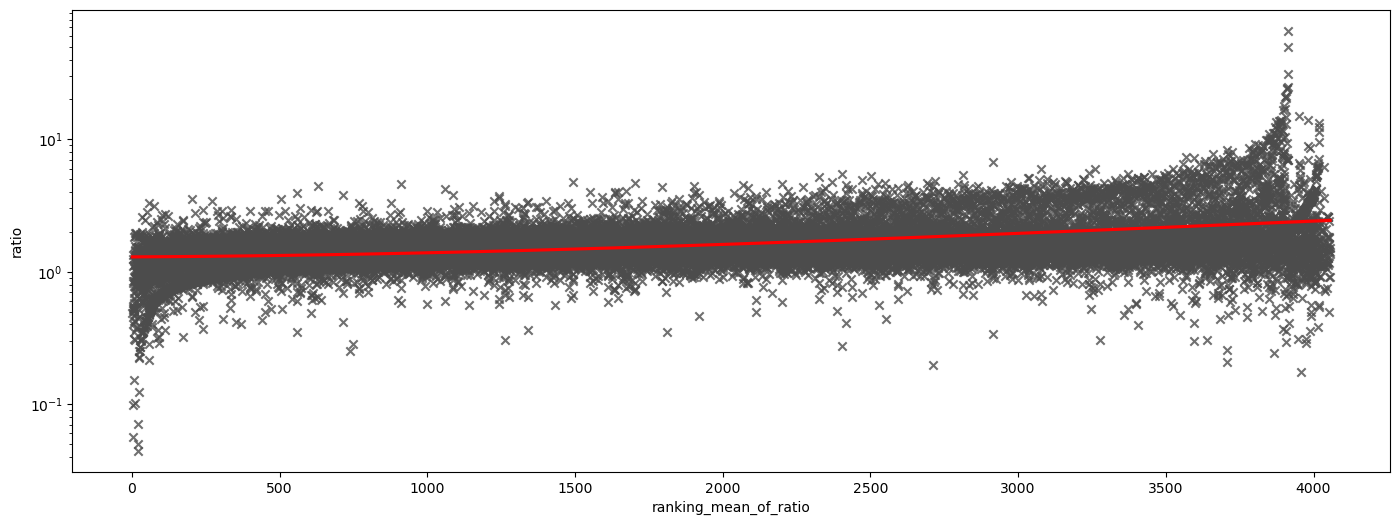

In [118]:
index =0
tmp_ratio = []
tmp_ranking = []
tmp_stddev = []
for line in result['ratio'].tolist():
    if (np.isnan(line) == False) and (line < np.inf):
        tmp_ratio.append(line)
        tmp_ranking.append(result['ranking_mean_of_ratio'].tolist()[index])
        tmp_stddev.append(result['std_of_ratio'].tolist()[index])
    index += 1

tmp_results = pd.DataFrame()
tmp_results['ratio']=tmp_ratio
tmp_results['ranking_mean_of_ratio']=tmp_ranking
tmp_results['std_dev']=tmp_stddev

plt.figure(figsize=(17, 6))
sns.regplot(tmp_results, x='ranking_mean_of_ratio', y='ratio', order=2, #ci=99,
            marker='x', color='.3', line_kws=dict(color='r'))
tmp_results = tmp_results.sort_values('ranking_mean_of_ratio')
tmp_results
plt.yscale('log')

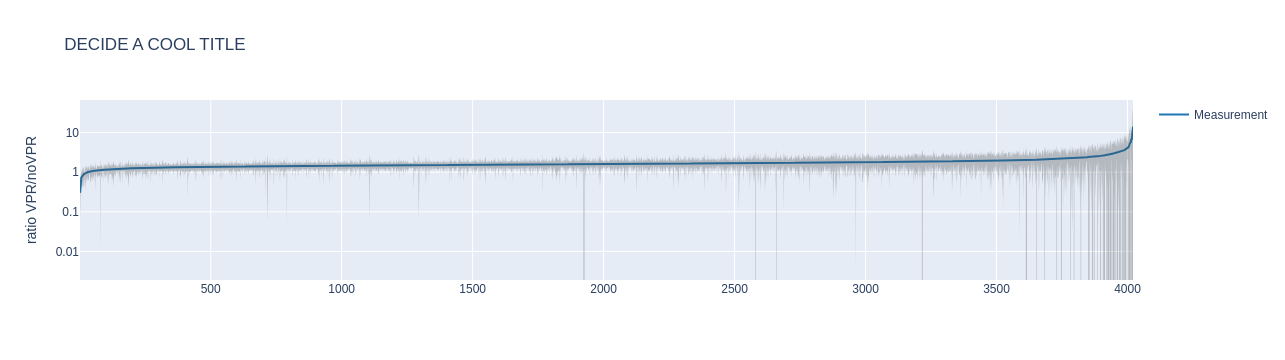

In [131]:
fig = go.Figure([
    go.Scatter(
        name='Measurement',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio'],
        mode='lines',
        line=dict(color='rgb(31, 119, 180)')
    ),
    go.Scatter(
        name='Upper Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']+df['std_of_ratio'],
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False
    ),
    go.Scatter(
        name='Lower Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']-df['std_of_ratio'],
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(68, 68, 68, 0.3)',
        fill='tonexty',
        showlegend=False
    )
])
fig.update_layout(
    yaxis_title='ratio VPR/noVPR',
    title='DECIDE A COOL TITLE',
    hovermode="x"
)
fig.update_yaxes(type="log")
fig.write_html("./ranking_with_std_dev_of_ratios_log.html")
fig.show()


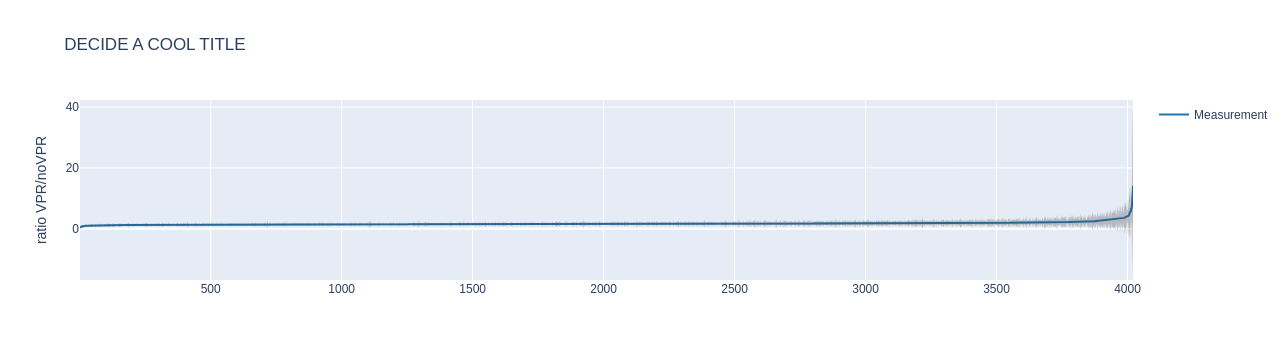

In [132]:
fig = go.Figure([
    go.Scatter(
        name='Measurement',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio'],
        mode='lines',
        line=dict(color='rgb(31, 119, 180)')
    ),
    go.Scatter(
        name='Upper Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']+df['std_of_ratio'],
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False
    ),
    go.Scatter(
        name='Lower Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']-df['std_of_ratio'],
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(68, 68, 68, 0.3)',
        fill='tonexty',
        showlegend=False
    )
])
fig.update_layout(
    yaxis_title='ratio VPR/noVPR',
    title='DECIDE A COOL TITLE',
    hovermode="x"
)
#fig.update_yaxes(type="log")
fig.write_html("./ranking_with_std_dev_of_ratios_not_log.html")
fig.show()



In [122]:
result

,ratio,ranking,prot,sample,mean_of_ratio,std_of_ratio,ranking_mean_of_ratio
4044,NaN,0,Q8BNY6,rep 1,NaN,NaN,4045
8100,0.000000,0,Q8BNY6,rep 2,NaN,NaN,4045
12156,0.000000,0,Q8BNY6,rep 3,NaN,NaN,4045
16212,0.000000,0,Q8BNY6,rep 4,NaN,NaN,4045
20268,0.000000,0,Q8BNY6,rep 5,NaN,NaN,4045
...,...,...,...,...,...,...,...
7980,inf,4055,Q9D486,rep 2,inf,NaN,3925
12036,inf,4055,Q9D486,rep 3,inf,NaN,3925
16092,inf,4055,Q9D486,rep 4,inf,NaN,3925
20148,inf,4055,Q9D486,rep 5,inf,NaN,3925


In [133]:
import os

if not os.path.exists("images"):
    os.mkdir("images")

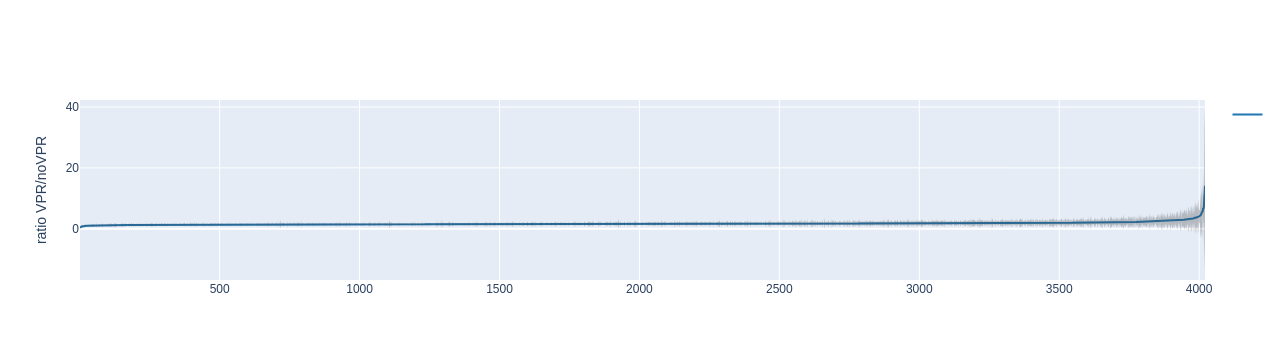

In [142]:
fig = go.Figure([
    go.Scatter(
        name='',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio'],
        mode='lines',
        line=dict(color='rgb(31, 119, 180)')
    ),
    go.Scatter(
        name='Upper Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']+df['std_of_ratio'],
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False
    ),
    go.Scatter(
        name='Lower Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']-df['std_of_ratio'],
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(68, 68, 68, 0.3)',
        fill='tonexty',
        showlegend=False
    )
])
fig.update_layout(
    yaxis_title='ratio VPR/noVPR',
    title='',
    hovermode="x"
)
#fig.update_yaxes(type="log")
#fig.write_html("./ranking_with_std_dev_of_ratios_not_log.html")
fig.write_image("./ranking_with_std_dev_of_ratios_not_log.svg")
fig.show()




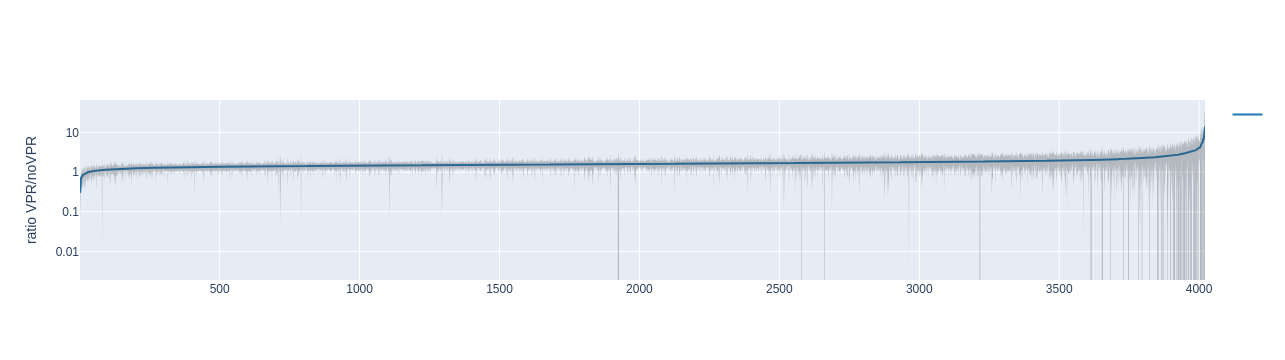

In [141]:
fig = go.Figure([
    go.Scatter(
        name='',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio'],
        mode='lines',
        line=dict(color='rgb(31, 119, 180)')
    ),
    go.Scatter(
        name='Upper Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']+df['std_of_ratio'],
        mode='lines',
        marker=dict(color="#444"),
        line=dict(width=0),
        showlegend=False
    ),
    go.Scatter(
        name='Lower Bound',
        x=df['ranking_mean_of_ratio'],
        y=df['mean_of_ratio']-df['std_of_ratio'],
        marker=dict(color="#444"),
        line=dict(width=0),
        mode='lines',
        fillcolor='rgba(68, 68, 68, 0.3)',
        fill='tonexty',
        showlegend=False
    )
])
fig.update_layout(
    yaxis_title='ratio VPR/noVPR',
    title='',
    hovermode="x"
)
fig.update_yaxes(type="log")

fig.write_image("./ranking_with_std_dev_of_ratios_log.svg")
fig.show()




In [ ]:
#!pip install -U kaleido

# the change in ranking problem 

In [ ]:
df.loc['O55201'] #Supt5h

In [ ]:
df.loc['Q8CFQ3'] # Aqr

In [ ]:
df.loc['Q8BWZ3'] # Naa25

In [ ]:
df.loc['P61080'] # Ube2d1

In [ ]:
adata

In [ ]:
adata.var_names = [str(x) for x in adata.var['Master Protein Accessions'].tolist()]
adata.var_names_make_unique()

In [ ]:
sc.pl.violin(adata, keys=['P61080', 'Q8BWZ3', 'Q8CFQ3', 'O55201'], groupby='VPR_condition')

In [ ]:
sc.pl.violin(adata, keys=['P61080', 'Q8BWZ3', 'Q8CFQ3', 'O55201'], groupby='replicates')

In [ ]:
sc.pl.violin(adata, keys=['P61080', 'Q8BWZ3', 'Q8CFQ3', 'O55201'], groupby='VPR_condition', layer='raw_counts_2')

In [ ]:
sc.pl.violin(adata, keys=['P61080', 'Q8BWZ3', 'Q8CFQ3', 'O55201'], groupby='replicates', layer='raw_counts_2')

In [ ]:
adata

In [ ]:
key = []
for line in adata.var_names.tolist():
    if 'O55201' in line:
        key.append(line)
sc.pl.violin(adata, keys=key, groupby='VPR_condition', layer='raw_counts_2')

In [ ]:
key

In [ ]:
sc.pl.violin(adata, keys=key, groupby='VPR_condition', layer='raw_counts_2')

In [ ]:
key = []
for line in adata.var_names.tolist():
    if 'P61080' in line:
        key.append(line)
sc.pl.violin(adata, keys=key, groupby='VPR_condition', layer='raw_counts_2')
#sc.pl.violin(adata, keys=key, groupby='VPR_condition', layer='raw_counts_2')

# Most differential proteins between VPR and noVPR


In [129]:
adata_prot.var

""
P35282
O88545
O09131
Q6PEE2
Q8BX17
...
P27659
P22682
Q01730
Q8K2C7


In [144]:
gene_name = []
missing_gene_names = []

for prot in adata_prot.var.index.tolist():
    
    if prot not in df_names.index.tolist():
        #print(prot)
        gene_name.append('missing protein name')
        missing_gene_names.append(prot)
    elif type(df_names.loc[prot]['gene name']) ==str:
        gene_name.append(df_names.loc[prot]['gene name'])
    else:
        gene_name.append(df_names.loc[prot]['gene name'].tolist()[0])
len(gene_name)
adata_prot.var['gene_name'] = gene_name

In [145]:
adata_prot.var['prot_id'] =adata_prot.var_names.tolist()
adata_prot.var_names = adata_prot.var['gene_name'].tolist()

In [242]:
sc.tl.rank_genes_groups?

Signature:
sc.tl.rank_genes_groups(
    adata: 'AnnData',
    groupby: 'str',
    *,
    mask_var: 'NDArray[np.bool_] | str | None' = None,
    use_raw: 'bool | None' = None,
    groups: "Literal['all'] | Iterable[str]" = 'all',
    reference: 'str' = 'rest',
    n_genes: 'int | None' = None,
    rankby_abs: 'bool' = False,
    pts: 'bool' = False,
    key_added: 'str | None' = None,
    copy: 'bool' = False,
    method: '_Method | None' = None,
    corr_method: '_CorrMethod' = 'benjamini-hochberg',
    tie_correct: 'bool' = False,
    layer: 'str | None' = None,
    **kwds,
) -> 'AnnData | None'
Docstring:
Rank genes for characterizing groups.

Expects logarithmized data.

Parameters
----------
adata : 'AnnData'
    Annotated data matrix.
groupby : 'str'
    The key of the observations grouping to consider.
mask_var : 'NDArray[np.bool_] | str | None', optional (default: None)
    Select subset of genes to use in statistical tests.
use_raw : 'bool | None', optional (default: None)
    

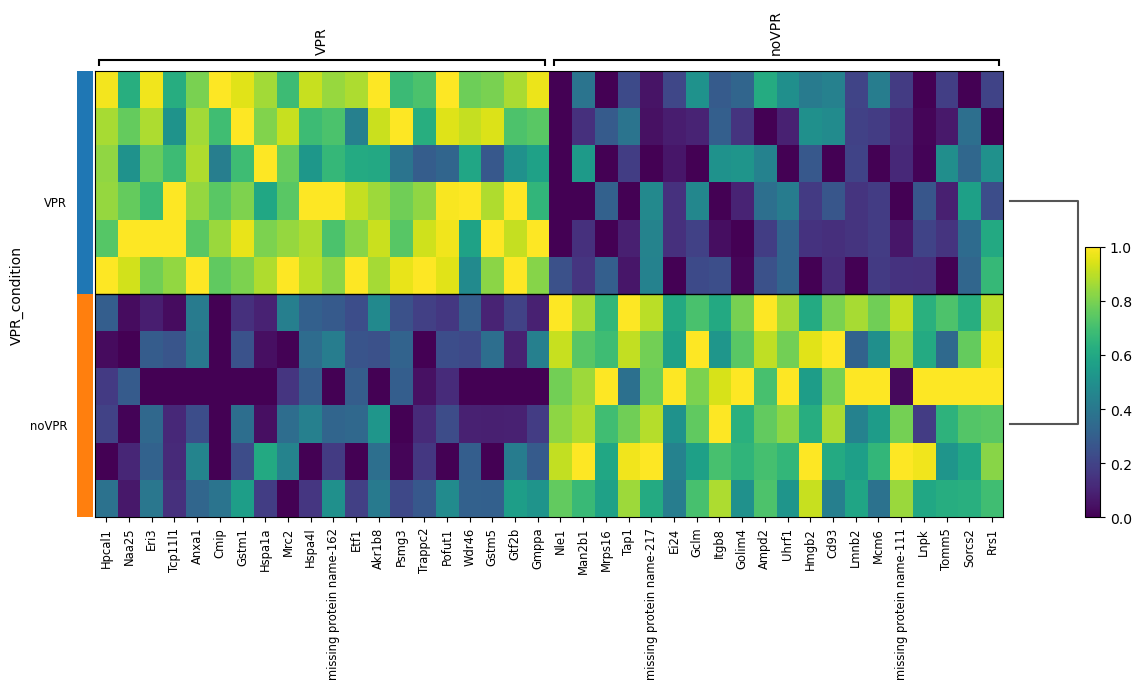

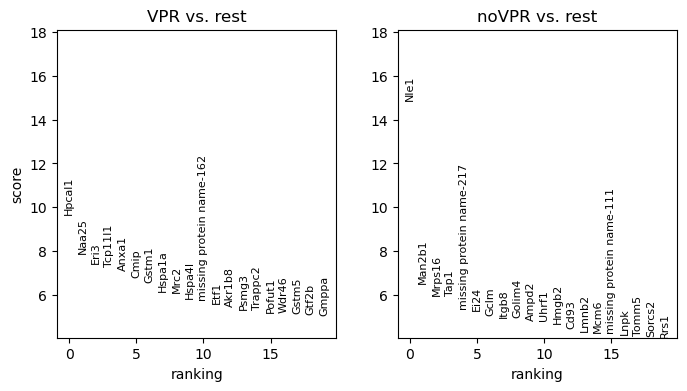

{'params': {'groupby': 'VPR_condition',
  'reference': 'rest',
  'method': 't-test_overestim_var',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('Hpcal1', 'Nle1'), ('Naa25', 'Man2b1'), ('Eri3', 'Mrps16'),
            ..., ('Mrps16', 'Eri3'), ('Man2b1', 'Naa25'),
            ('Nle1', 'Hpcal1')],
           dtype=[('VPR', 'O'), ('noVPR', 'O')]),
 'scores': rec.array([(  9.680859 , 14.851633 ), (  7.8919406,  6.528821 ),
            (  7.4342194,  5.9969487), ..., ( -5.9969487, -7.4342194),
            ( -6.528821 , -7.8919406), (-14.851633 , -9.680859 )],
           dtype=[('VPR', '<f4'), ('noVPR', '<f4')]),
 'pvals': rec.array([(5.87748235e-06, 4.52770275e-08),
            (4.76402908e-05, 1.90888794e-04),
            (2.83231759e-05, 1.34847071e-04), ...,
            (1.34847071e-04, 2.83231759e-05),
            (1.90888794e-04, 4.76402908e-05),
            (4.52770275e-08, 5.87748235e-06)],
           dtype=[('VPR', '<f8'), ('noVPR'

In [247]:
sc.tl.rank_genes_groups(adata_prot, groupby='VPR_condition', method='t-test_overestim_var')
sc.pl.rank_genes_groups_heatmap(adata_prot,  standard_scale='var', n_genes=20)
sc.pl.rank_genes_groups(adata_prot,  standard_scale='var', n_genes=20)
adata_prot.uns['rank_genes_groups']

In [248]:
prot_names = [x[0] for x in adata_prot.uns['rank_genes_groups']['names'].tolist()]
pvals = [x[0] for x in adata_prot.uns['rank_genes_groups']['pvals_adj'].tolist()]
tmp_df = pd.DataFrame()
tmp_df['prot_names'] = prot_names
tmp_df['adj_pvals'] = pvals
tmp_df.sort_values('adj_pvals')

,prot_names,adj_pvals
4059,Nle1,0.000184
0,Hpcal1,0.011931
2,Eri3,0.038331
1,Naa25,0.045275
5,Cmip,0.045275
...,...,...
2034,Atp6v1g1,0.997857
2038,Xrn2,0.997857
2035,Pfn1,0.998119
2037,Cnpy2,0.998932


In [241]:
tmp_df.sort_values('adj_pvals')[0:20]

,prot_names,adj_pvals
4059,Nle1,0.000184
0,Hpcal1,0.011931
2,Eri3,0.038331
1,Naa25,0.045275
5,Cmip,0.045275
9,Hspa4l,0.067675
4057,Mrps16,0.067675
4,Anxa1,0.067675
6,Gstm1,0.067675
3,Tcp11l1,0.067675


In [251]:
adata_prot2 =adata_prot.copy()
sc.pp.log1p(adata_prot2, layer='sum_peptides_raw_counts_2', base=2)
#sc.pp.log1p(adata_prot2, base=2)

In [252]:
sc.tl.rank_genes_groups(adata_prot2, groupby='VPR_condition', layer='sum_peptides_raw_counts_2', method='t-test_overestim_var')
#sc.tl.rank_genes_groups(adata_prot2, groupby='VPR_condition',)

In [253]:
adata_prot2.uns['rank_genes_groups']

{'params': {'groupby': 'VPR_condition',
  'reference': 'rest',
  'method': 't-test_overestim_var',
  'use_raw': False,
  'layer': 'sum_peptides_raw_counts_2',
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('Naa25', 'Nle1'), ('Dguok', 'Ncs1'), ('Pdzd8', 'Glipr2'), ...,
            ('Glipr2', 'Pdzd8'), ('Ncs1', 'Dguok'), ('Nle1', 'Naa25')],
           dtype=[('VPR', 'O'), ('noVPR', 'O')]),
 'scores': rec.array([( 9.931762 ,  5.3165517), ( 9.117373 ,  4.9802637),
            ( 7.1218987,  3.2607324), ..., (-3.2607324, -7.1218987),
            (-4.9802637, -9.117373 ), (-5.3165517, -9.931762 )],
           dtype=[('VPR', '<f4'), ('noVPR', '<f4')]),
 'pvals': rec.array([(1.78648497e-05, 3.06695062e-03),
            (5.89618344e-06, 4.17477573e-03),
            (6.53916437e-05, 1.40651038e-02), ...,
            (1.40651038e-02, 6.53916437e-05),
            (4.17477573e-03, 5.89618344e-06),
            (3.06695062e-03, 1.78648497e-05)],
           dtype=[('VPR', '<f8'), ('noVPR

In [254]:
prot_names = [x[0] for x in adata_prot2.uns['rank_genes_groups']['names'].tolist()]
pvals = [x[0] for x in adata_prot2.uns['rank_genes_groups']['pvals_adj'].tolist()]
tmp_df = pd.DataFrame()
tmp_df['prot_names'] = prot_names
tmp_df['adj_pvals'] = pvals
tmp_df.sort_values('adj_pvals')

,prot_names,adj_pvals
1,Dguok,0.023939
0,Naa25,0.036266
469,Scrib,0.080435
470,missing protein name-189,0.080435
471,Sccpdh,0.080435
...,...,...
3963,Rab24,0.989430
3959,Nars1,0.989706
3960,Pals2,0.993139
3962,missing protein name-208,0.993962


In [255]:
top_50_enrich = [x[0] for x in adata_prot.uns['rank_genes_groups']['names'][0:50]]
top_50_enrich

['Hpcal1',
 'Naa25',
 'Eri3',
 'Tcp11l1',
 'Anxa1',
 'Cmip',
 'Gstm1',
 'Hspa1a',
 'Mrc2',
 'Hspa4l',
 'missing protein name-162',
 'Etf1',
 'Akr1b8',
 'Psmg3',
 'Trappc2',
 'Pofut1',
 'Wdr46',
 'Gstm5',
 'Gtf2b',
 'Gmppa',
 'Ncald',
 'Psmb2',
 'Rtca',
 'Sfxn3',
 'missing protein name-119',
 'Actr1a',
 'Psmb1',
 'Me1',
 'Irf3',
 'Tmem9',
 'Tmem208',
 'Rpp30',
 'Snrpe',
 'Scrib',
 'Ifi211',
 'Atp6v1e1',
 'Gga1',
 'Trip12',
 'Ctnnd1',
 'Mrpl23',
 'Smad2',
 'Syne2',
 'Qars1',
 'missing protein name-51',
 'Bcat2',
 'Ublcp1',
 'Ccdc25',
 'Top3b',
 'Snx33',
 'Trappc4']

In [256]:
#sc.pl.rank_genes_groups?

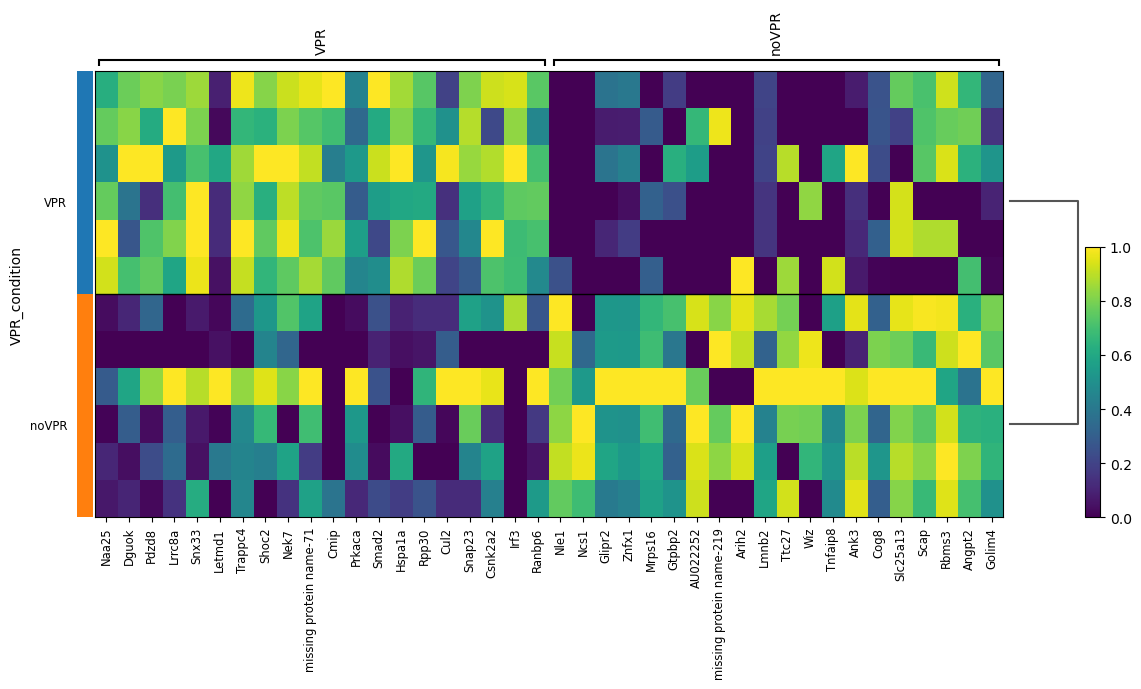

In [257]:
sc.pl.rank_genes_groups_heatmap(adata_prot2,  standard_scale='var', n_genes=20)

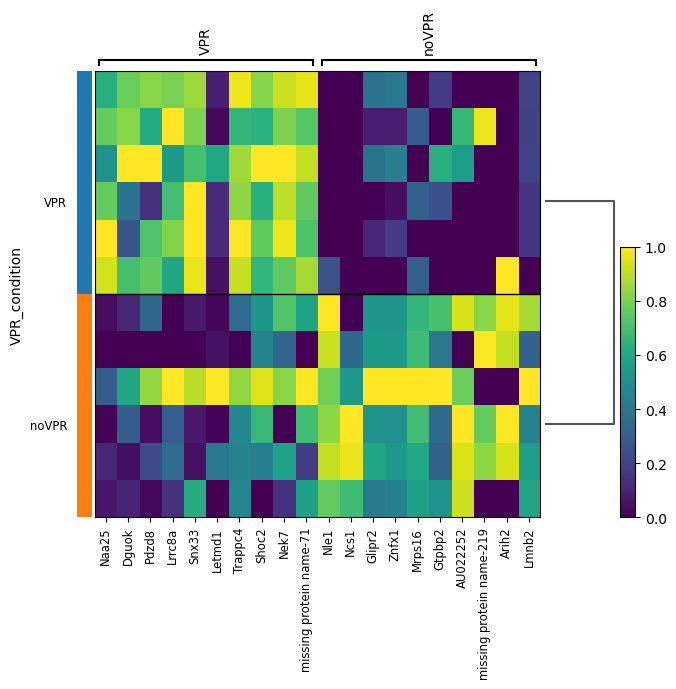

In [258]:
sc.pl.rank_genes_groups_heatmap(adata_prot2,  standard_scale='var')

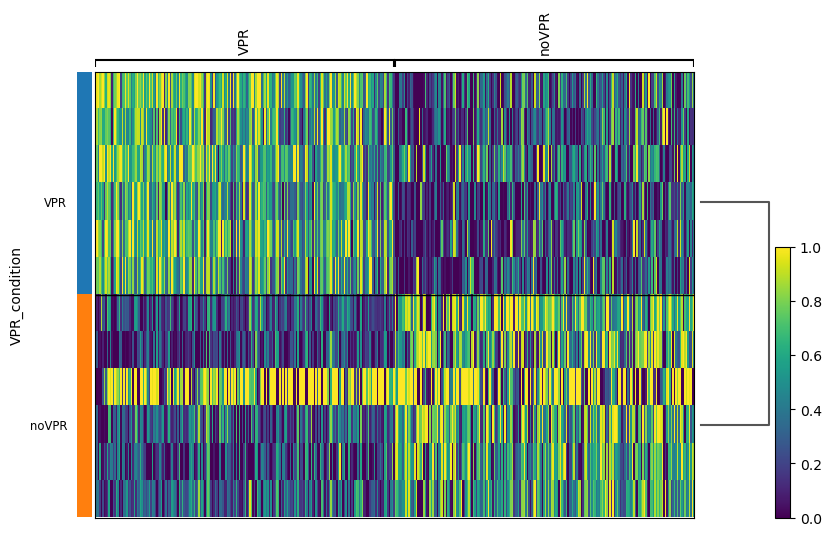

In [204]:
sc.pl.rank_genes_groups_heatmap(adata_prot,  standard_scale='var', n_genes=200)

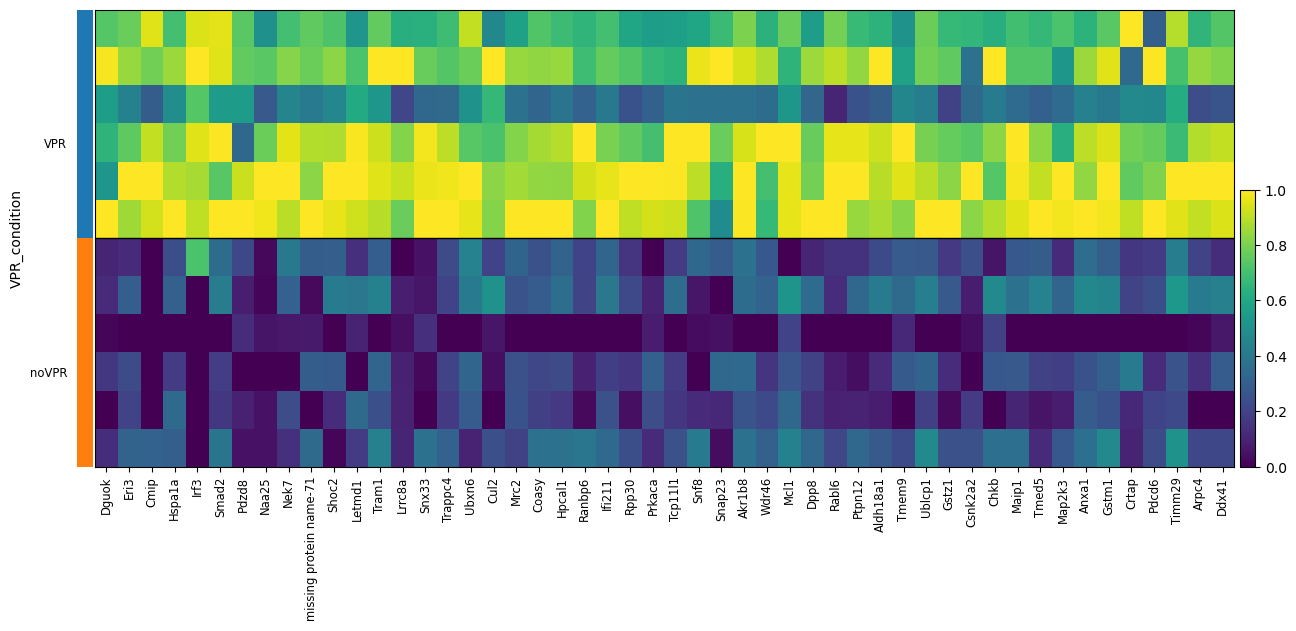

In [205]:
sc.pl.heatmap(adata_prot, var_names=top_50_enrich, groupby='VPR_condition', layer='sum_peptides_raw_counts_2', standard_scale='var')

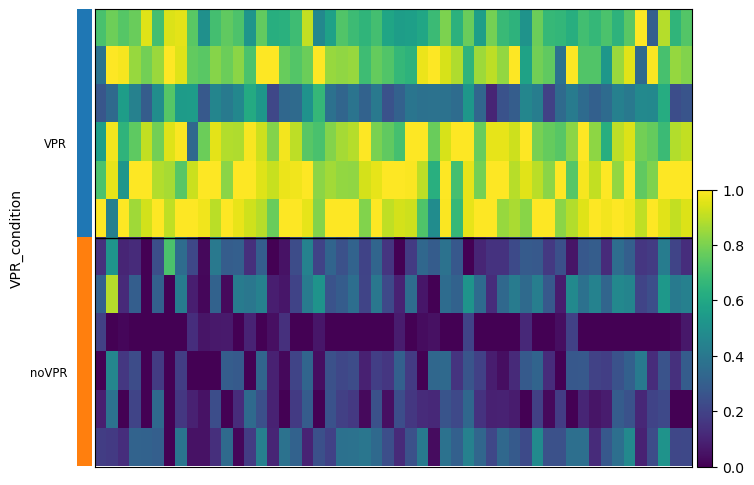

In [206]:
sc.pl.heatmap(adata_prot, var_names=['Aqr', 'Supt5']+top_50_enrich, groupby='VPR_condition', layer='sum_peptides_raw_counts_2', standard_scale='var')

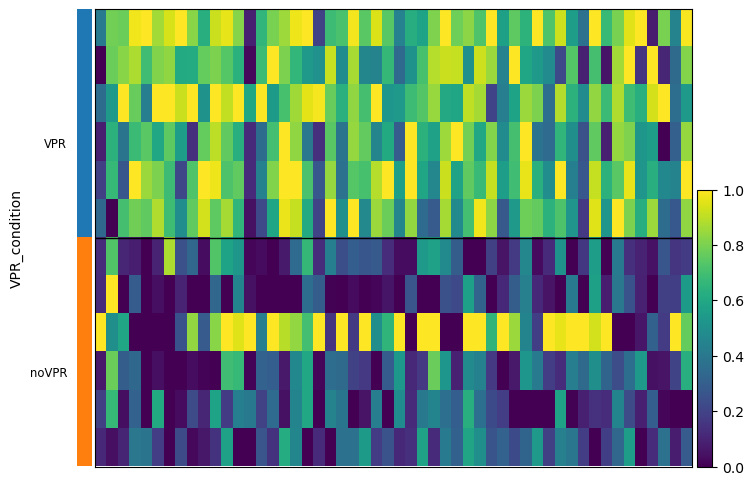

In [207]:
sc.pl.heatmap(adata_prot, var_names=['Aqr', 'Supt5']+top_50_enrich, groupby='VPR_condition', standard_scale='var')

In [151]:
adata_prot.var_names_make_unique()

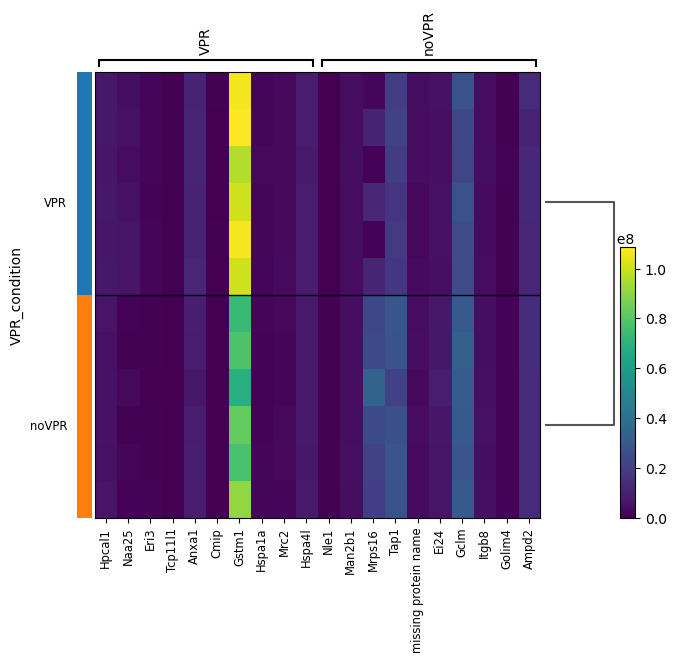

In [152]:
sc.pp.pca(adata_prot)
sc.pl.rank_genes_groups_heatmap(adata_prot)

In [166]:
adata_prot.obs

,VPR_condition,replicates,n_features,log_n_features,n_counts,log_n_counts,raw_abundance,VPR_condition_coordinates
"Abundances (Normalized): F1: Sample, noVPR",noVPR,R1,38828,4.589145,1.513230e+11,11.179905,1.126365e+11,0
"Abundances (Normalized): F2: Sample, noVPR",noVPR,R2,39227,4.593585,1.593717e+11,11.202411,1.421331e+11,0
"Abundances (Normalized): F3: Sample, noVPR",noVPR,R3,37484,4.573846,1.356822e+11,11.132523,5.218524e+10,0
"Abundances (Normalized): F4: Sample, noVPR",noVPR,R4,39068,4.591821,1.529396e+11,11.184520,1.031366e+11,0
"Abundances (Normalized): F5: Sample, noVPR",noVPR,R5,38982,4.590864,1.540079e+11,11.187543,9.980697e+10,0
"Abundances (Normalized): F6: Sample, noVPR",noVPR,R6,39133,4.592543,1.521480e+11,11.182266,1.206221e+11,0
"Abundances (Normalized): F7: Sample, VPR",VPR,R1,39203,4.593319,1.537516e+11,11.186820,1.421036e+11,1
"Abundances (Normalized): F8: Sample, VPR",VPR,R2,39316,4.594569,1.552730e+11,11.191096,1.719343e+11,1
"Abundances (Normalized): F9: Sample, VPR",VPR,R3,39120,4.592399,1.506621e+11,11.178004,1.020953e+11,1
"Abundances (Normalized): F10: Sample, VPR",VPR,R4,39399,4.595485,1.506110e+11,11.177857,1.756140e+11,1


In [168]:
tmp_df = pd.DataFrame(adata_prot.X).transpose()
tmp_df.columns = ["".join(x.split(':')[1:]) for x in adata_prot.obs_names.tolist()]
tmp_df.columns

Index([' F1 Sample, noVPR', ' F2 Sample, noVPR', ' F3 Sample, noVPR',
       ' F4 Sample, noVPR', ' F5 Sample, noVPR', ' F6 Sample, noVPR',
       ' F7 Sample, VPR', ' F8 Sample, VPR', ' F9 Sample, VPR',
       ' F10 Sample, VPR', ' F11 Sample, VPR', ' F12 Sample, VPR'],
      dtype='object')

In [115]:
sns.displot(tmp_df[' F1 Sample, noVPR'])
plt.xscale('log')
sns.displot(tmp_df[' F2 Sample, noVPR'])
plt.xscale('log')

KeyError: ' F1 Sample, noVPR'